In [24]:
import numpy as np
import pandas as pd
import os
import re
import pickle
from scipy import sparse


from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score,
    f1_score, roc_auc_score, 
    confusion_matrix,
    classification_report, 
    roc_curve,
    confusion_matrix,
    make_scorer
)

from sklearn.pipeline import make_pipeline
from sklearn.model_selection import (
train_test_split, 
cross_val_score,
StratifiedKFold, 
learning_curve, 
GridSearchCV, 
RandomizedSearchCV)

from scipy.stats import loguniform

from sklearn.ensemble import BaggingClassifier, RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import SGDClassifier

import xgboost as xgb
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials, space_eval

# 1. Ucitavamo podatke

In [25]:
data_dir = "preprocessed_data"

labels = np.load(os.path.join(data_dir, "labels.npy"))

feature_names_count_stripped = np.load(os.path.join(data_dir, "feature_names_count_stripped.npy"),
                                      allow_pickle=True)
feature_names_count_prefixed = np.load(os.path.join(data_dir, "feature_names_count_prefixed.npy"),
                                      allow_pickle=True)

X_tfidf_reduced_stripped = sparse.load_npz(os.path.join(data_dir, "X_tfidf_reduced_stripped.npz"))
X_tfidf_reduced_prefixed = sparse.load_npz(os.path.join(data_dir, "X_tfidf_reduced_prefixed.npz"))
X_tfidf_full_stripped = sparse.load_npz(os.path.join(data_dir, "X_tfidf_full_stripped.npz"))
X_tfidf_full_prefixed = sparse.load_npz(os.path.join(data_dir, "X_tfidf_full_prefixed.npz"))

X_lsa_reduced_stripped = np.load(os.path.join(data_dir, "X_lsa_reduced_stripped.npy"))
X_lsa_reduced_prefixed = np.load(os.path.join(data_dir, "X_lsa_reduced_prefixed.npy"))
X_lsa_full_stripped = np.load(os.path.join(data_dir, "X_lsa_full_stripped.npy"))
X_lsa_full_prefixed = np.load(os.path.join(data_dir, "X_lsa_full_prefixed.npy"))

with open(os.path.join(data_dir, "feature_names_tfidf.pkl"), "rb") as f:
    feature_names_tfidf = pickle.load(f)
feature_names_reduced_stripped = feature_names_tfidf["feature_names_tfidf_reduced_stripped"]
feature_names_reduced_prefixed = feature_names_tfidf["feature_names_tfidf_reduced_prefixed"]
feature_names_full_stripped = feature_names_tfidf["feature_names_tfidf_full_stripped"]
feature_names_full_prefixed = feature_names_tfidf["feature_names_tfidf_full_prefixed"]

datasets = {
    "Reduced Stripped": X_lsa_reduced_stripped,
    "Reduced Prefixed": X_lsa_reduced_prefixed,
    "Full Stripped":    X_lsa_full_stripped,
    "Full Prefixed":    X_lsa_full_prefixed,
}

# 2. Svaki skup podataka dalje delimo na skup za treniranje i skup za testiranje

In [26]:
y = labels
cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=8)

splits = {}
for name, X in datasets.items():
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=8, stratify=y
    )
    splits[name] = {
        'X_train': X_train,
        'X_test':  X_test,
        'y_train': y_train,
        'y_test':  y_test
    }

## Algoritam 1: Bagging
### Pravimo funkciju koja trenira i testira bagging klasifikator nad datim skupom podataka.

In [27]:
def run_bagging_classification(X_train, X_test, y_train, y_test, dataset_name, cv):
    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")
    print(f"Train size: {X_train.shape[0]}  Test size: {X_test.shape[0]}")

    baseline_tree = DecisionTreeClassifier(random_state=8)
    baseline_tree.fit(X_train, y_train)
    baseline_preds = baseline_tree.predict(X_test)
    baseline_proba = baseline_tree.predict_proba(X_test)[:, 1]

    print("\n── Baseline Single Decision Tree ─────────────────────────")
    print(f"Accuracy:  {accuracy_score(y_test, baseline_preds):.4f}")
    print(f"Precision: {precision_score(y_test, baseline_preds):.4f}")
    print(f"Recall:    {recall_score(y_test, baseline_preds):.4f}")
    print(f"F1:        {f1_score(y_test, baseline_preds):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, baseline_proba):.4f}")

    param_dist_bagging = {
        'n_estimators': [50, 100, 150],
        'max_samples':  [0.5, 0.6, 0.7, 0.8, 0.9],
        'max_features': [0.5, 0.6, 0.7, 0.8],
        'estimator__max_depth': [5, 10, 15, 20],
        'estimator__min_samples_leaf': [1, 2, 4],
        'estimator__min_samples_split': [2, 5]
    }

    base_model = BaggingClassifier(
        estimator=DecisionTreeClassifier(random_state=8),
        random_state=8,
        n_jobs=-1,
        bootstrap=True,
        oob_score=True
    )

    random_search = RandomizedSearchCV(
        base_model,
        param_distributions=param_dist_bagging,
        n_iter=30,
        scoring='roc_auc',
        cv=cv,
        error_score='raise',
        verbose=1,
        random_state=8,
        #n_jobs=-1
    )
    random_search.fit(X_train, y_train)

    best_bag = random_search.best_estimator_
    y_pred = best_bag.predict(X_test)
    y_proba = best_bag.predict_proba(X_test)[:, 1]

    print("\n── Bagging Classifier Results ───────────────────────────")
    print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
    for k, v in random_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}  (baseline: {accuracy_score(y_test, baseline_preds):.4f})")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}  (baseline: {precision_score(y_test, baseline_preds):.4f})")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}  (baseline: {recall_score(y_test, baseline_preds):.4f})")
    print(f"F1:        {f1_score(y_test, y_pred):.4f}  (baseline: {f1_score(y_test, baseline_preds):.4f})")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}  (baseline: {roc_auc_score(y_test, baseline_proba):.4f})")

    print("\n── Classification Report ────────────────────────────────")
    print(classification_report(y_test, y_pred, target_names=['Rejected', 'Accepted']))

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Rejected', 'Accepted'],
                yticklabels=['Rejected', 'Accepted'])
    axes[0].set_title(f'Confusion Matrix — {dataset_name}')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
    axes[1].plot(fpr, tpr, label=f'Bagging (AUC={roc_auc_score(y_test, y_proba):.3f})')
    axes[1].plot(fpr_base, tpr_base, label=f'Baseline (AUC={roc_auc_score(y_test, baseline_proba):.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Bagging Classifier — {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    return best_bag, {
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_proba),
        'cv_roc_auc': random_search.best_score_,
        'best_params': random_search.best_params_
    }

### Pozivamo funkciju nad svim skupovima podataka i cuvamo rezultate.


Dataset: Reduced Stripped
Train size: 2612  Test size: 653

── Baseline Single Decision Tree ─────────────────────────
Accuracy:  0.8116
Precision: 0.8256
Recall:    0.8370
F1:        0.8313
ROC-AUC:   0.8085
Fitting 3 folds for each of 30 candidates, totalling 90 fits

── Bagging Classifier Results ───────────────────────────
Best CV ROC-AUC: 0.9410
  n_estimators: 100
  max_samples: 0.9
  max_features: 0.6
  estimator__min_samples_split: 2
  estimator__min_samples_leaf: 2
  estimator__max_depth: 15
Accuracy:  0.8622  (baseline: 0.8116)
Precision: 0.8366  (baseline: 0.8256)
Recall:    0.9337  (baseline: 0.8370)
F1:        0.8825  (baseline: 0.8313)
ROC-AUC:   0.9365  (baseline: 0.8085)

── Classification Report ────────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.90      0.77      0.83       291
    Accepted       0.84      0.93      0.88       362

    accuracy                           0.86       653
   macro avg       0.87   

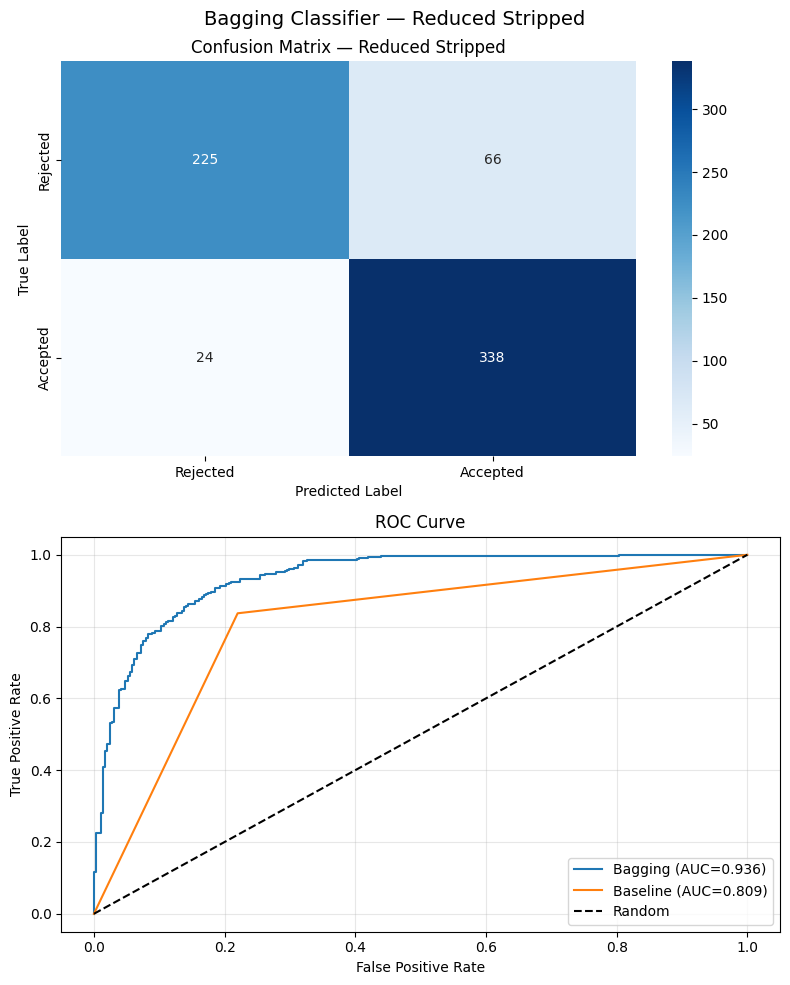


Dataset: Reduced Prefixed
Train size: 2612  Test size: 653

── Baseline Single Decision Tree ─────────────────────────
Accuracy:  0.7963
Precision: 0.8053
Recall:    0.8343
F1:        0.8195
ROC-AUC:   0.7970
Fitting 3 folds for each of 30 candidates, totalling 90 fits

── Bagging Classifier Results ───────────────────────────
Best CV ROC-AUC: 0.9352
  n_estimators: 150
  max_samples: 0.5
  max_features: 0.5
  estimator__min_samples_split: 5
  estimator__min_samples_leaf: 1
  estimator__max_depth: 20
Accuracy:  0.8423  (baseline: 0.7963)
Precision: 0.8278  (baseline: 0.8053)
Recall:    0.9033  (baseline: 0.8343)
F1:        0.8639  (baseline: 0.8195)
ROC-AUC:   0.9206  (baseline: 0.7970)

── Classification Report ────────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.86      0.77      0.81       291
    Accepted       0.83      0.90      0.86       362

    accuracy                           0.84       653
   macro avg       0.85   

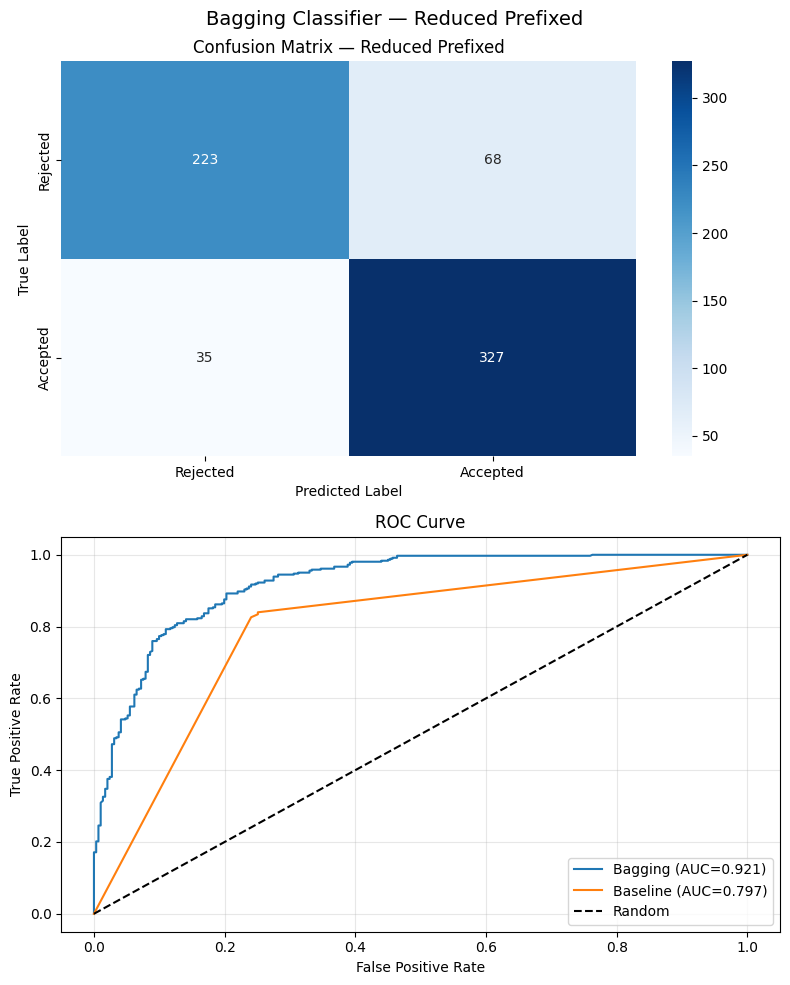


Dataset: Full Stripped
Train size: 2612  Test size: 653

── Baseline Single Decision Tree ─────────────────────────
Accuracy:  0.7994
Precision: 0.8291
Recall:    0.8039
F1:        0.8163
ROC-AUC:   0.7988
Fitting 3 folds for each of 30 candidates, totalling 90 fits

── Bagging Classifier Results ───────────────────────────
Best CV ROC-AUC: 0.9416
  n_estimators: 150
  max_samples: 0.9
  max_features: 0.6
  estimator__min_samples_split: 2
  estimator__min_samples_leaf: 2
  estimator__max_depth: 10
Accuracy:  0.8606  (baseline: 0.7994)
Precision: 0.8346  (baseline: 0.8291)
Recall:    0.9337  (baseline: 0.8039)
F1:        0.8814  (baseline: 0.8163)
ROC-AUC:   0.9335  (baseline: 0.7988)

── Classification Report ────────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.90      0.77      0.83       291
    Accepted       0.83      0.93      0.88       362

    accuracy                           0.86       653
   macro avg       0.87      

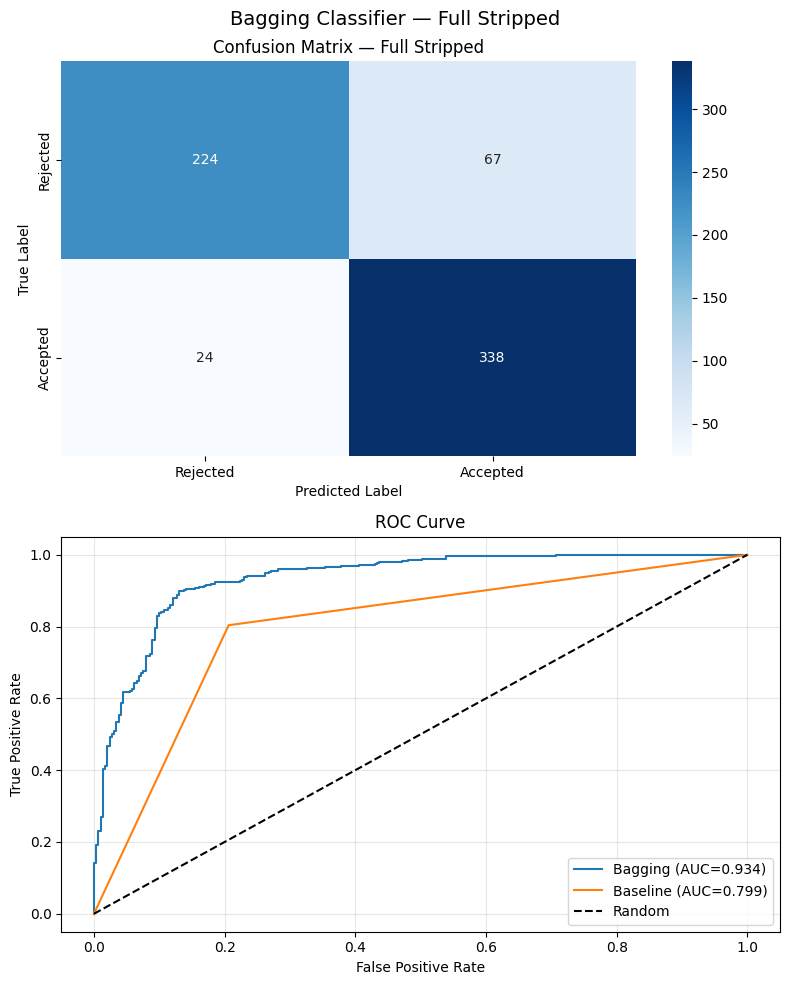


Dataset: Full Prefixed
Train size: 2612  Test size: 653

── Baseline Single Decision Tree ─────────────────────────
Accuracy:  0.8040
Precision: 0.8250
Recall:    0.8204
F1:        0.8227
ROC-AUC:   0.8020
Fitting 3 folds for each of 30 candidates, totalling 90 fits

── Bagging Classifier Results ───────────────────────────
Best CV ROC-AUC: 0.9376
  n_estimators: 100
  max_samples: 0.8
  max_features: 0.6
  estimator__min_samples_split: 5
  estimator__min_samples_leaf: 2
  estimator__max_depth: 20
Accuracy:  0.8560  (baseline: 0.8040)
Precision: 0.8384  (baseline: 0.8250)
Recall:    0.9171  (baseline: 0.8204)
F1:        0.8760  (baseline: 0.8227)
ROC-AUC:   0.9301  (baseline: 0.8020)

── Classification Report ────────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.88      0.78      0.83       291
    Accepted       0.84      0.92      0.88       362

    accuracy                           0.86       653
   macro avg       0.86      

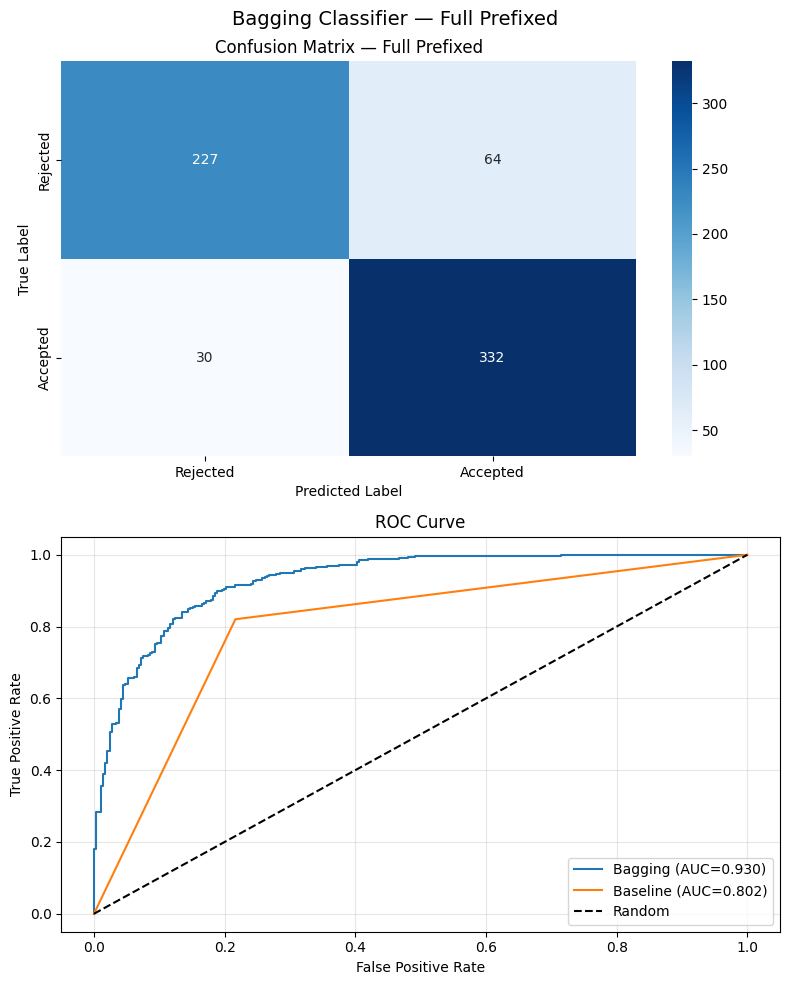

In [28]:
bagging_results = {}

for name in datasets.keys():
    split = splits[name]
    _, metrics = run_bagging_classification(
        X_train=split['X_train'],
        X_test=split['X_test'],
        y_train=split['y_train'],
        y_test=split['y_test'],
        dataset_name=name,
        cv=cv
    )
    bagging_results[name] = metrics

### Prikaz rezultata

In [29]:
summary_bagging = pd.DataFrame([
    {
        'Dataset': name,
        'CV ROC-AUC': res['cv_roc_auc'],
        'Test ROC-AUC': res['test_roc_auc'],
        'Test Accuracy': res['test_accuracy'],
        'Best Params': res['best_params']
    }
    for name, res in bagging_results.items()
])
display(summary_bagging)

,Dataset,CV ROC-AUC,Test ROC-AUC,Test Accuracy,Best Params
0,Reduced Stripped,0.941000,0.936464,0.862175,"{'n_estimators': 100, 'max_samples': 0.9, 'max..."
1,Reduced Prefixed,0.935215,0.920611,0.842266,"{'n_estimators': 150, 'max_samples': 0.5, 'max..."
2,Full Stripped,0.941631,0.933540,0.860643,"{'n_estimators': 150, 'max_samples': 0.9, 'max..."
3,Full Prefixed,0.937614,0.930132,0.856049,"{'n_estimators': 100, 'max_samples': 0.8, 'max..."


## Algoritam 2: Random Forest
### Pravimo funkciju koja trenira i testira frandom forest klasifikator nad datim skupom podataka.

In [33]:
def run_random_forest_classification(X_train, X_test, y_train, y_test, dataset_name, cv):
    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")
    print(f"Train size: {X_train.shape[0]}  Test size: {X_test.shape[0]}")

    baseline_tree = DecisionTreeClassifier(random_state=8)
    baseline_tree.fit(X_train, y_train)
    baseline_preds = baseline_tree.predict(X_test)
    baseline_proba = baseline_tree.predict_proba(X_test)[:, 1]

    print("\n── Baseline Single Decision Tree ─────────────────────────")
    print(f"Accuracy:  {accuracy_score(y_test, baseline_preds):.4f}")
    print(f"Precision: {precision_score(y_test, baseline_preds):.4f}")
    print(f"Recall:    {recall_score(y_test, baseline_preds):.4f}")
    print(f"F1:        {f1_score(y_test, baseline_preds):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, baseline_proba):.4f}")

    param_dist_rf = {
        'n_estimators': [50, 100, 150],
        'max_depth': [5, 10, 15, 20],
        'max_features': ['sqrt', 'log2', 0.1, 0.2, 0.3, 0.5],
        'min_samples_split': [2, 5, 10],
        'min_samples_leaf': [1, 2, 4],
        'bootstrap': [True]
    }

    base_rf = RandomForestClassifier(random_state=8, n_jobs=-1, oob_score=True)

    random_search = RandomizedSearchCV(
        base_rf,
        param_distributions=param_dist_rf,
        n_iter=30,
        scoring='roc_auc',
        cv=cv,
        verbose=0,
        random_state=8,
    )
    random_search.fit(X_train, y_train)

    best_rf = random_search.best_estimator_
    y_pred = best_rf.predict(X_test)
    y_proba = best_rf.predict_proba(X_test)[:, 1]

    print("\n── Random Forest Classifier Results ──────────────────────")
    print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
    for k, v in random_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}  (baseline: {accuracy_score(y_test, baseline_preds):.4f})")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}  (baseline: {precision_score(y_test, baseline_preds):.4f})")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}  (baseline: {recall_score(y_test, baseline_preds):.4f})")
    print(f"F1:        {f1_score(y_test, y_pred):.4f}  (baseline: {f1_score(y_test, baseline_preds):.4f})")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}  (baseline: {roc_auc_score(y_test, baseline_proba):.4f})")

    print("\n── Classification Report ────────────────────────────────")
    print(classification_report(y_test, y_pred, target_names=['Rejected', 'Accepted']))

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Rejected', 'Accepted'],
                yticklabels=['Rejected', 'Accepted'])
    axes[0].set_title(f'Confusion Matrix — {dataset_name}')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    fpr, tpr, _ = roc_curve(y_test, y_proba)
    fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
    axes[1].plot(fpr, tpr, label=f'Random Forest (AUC={roc_auc_score(y_test, y_proba):.3f})')
    axes[1].plot(fpr_base, tpr_base, label=f'Baseline (AUC={roc_auc_score(y_test, baseline_proba):.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Random Forest Classifier — {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    metrics = {
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_proba),
        'cv_roc_auc': random_search.best_score_,
        'best_params': random_search.best_params_
    }
    return best_rf, metrics

### Pozivamo funkciju nad svim skupovima podataka i cuvamo rezultate.


Dataset: Reduced Stripped
Train size: 2612  Test size: 653

── Baseline Single Decision Tree ─────────────────────────
Accuracy:  0.8116
Precision: 0.8256
Recall:    0.8370
F1:        0.8313
ROC-AUC:   0.8085

── Random Forest Classifier Results ──────────────────────
Best CV ROC-AUC: 0.9387
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.1
  max_depth: 20
  bootstrap: True
Accuracy:  0.8591  (baseline: 0.8116)
Precision: 0.8325  (baseline: 0.8256)
Recall:    0.9337  (baseline: 0.8370)
F1:        0.8802  (baseline: 0.8313)
ROC-AUC:   0.9405  (baseline: 0.8085)

── Classification Report ────────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.90      0.77      0.83       291
    Accepted       0.83      0.93      0.88       362

    accuracy                           0.86       653
   macro avg       0.87      0.85      0.85       653
weighted avg       0.86      0.86      0.86       653



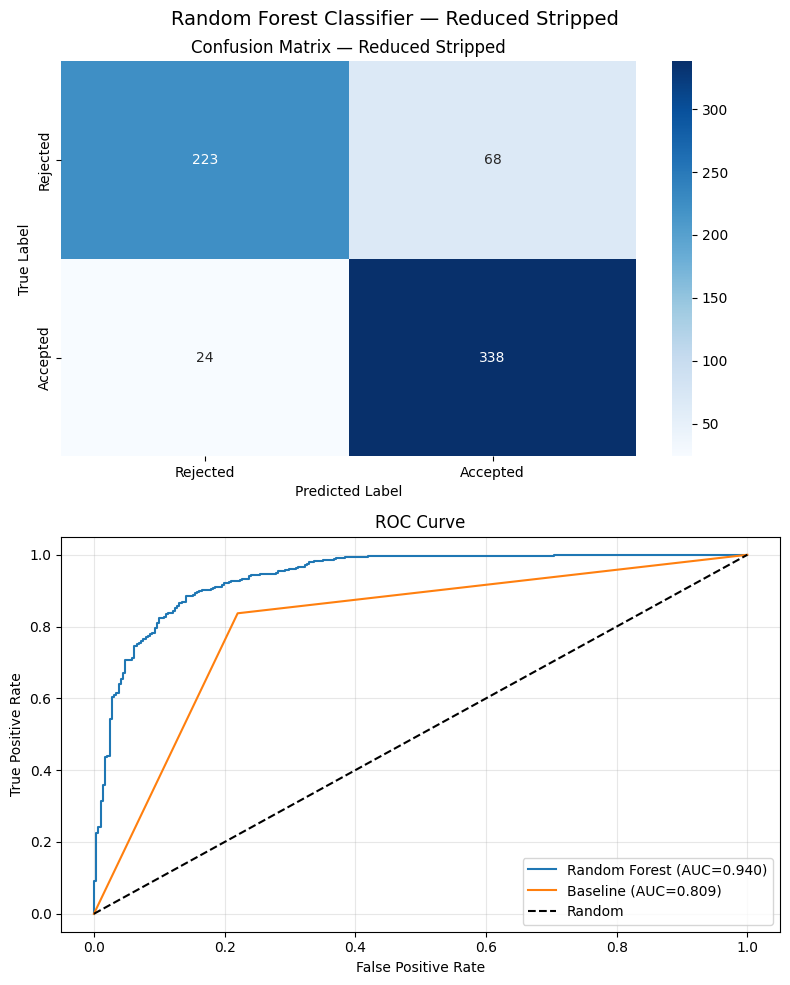


Dataset: Reduced Prefixed
Train size: 2612  Test size: 653

── Baseline Single Decision Tree ─────────────────────────
Accuracy:  0.7963
Precision: 0.8053
Recall:    0.8343
F1:        0.8195
ROC-AUC:   0.7970

── Random Forest Classifier Results ──────────────────────
Best CV ROC-AUC: 0.9392
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.1
  max_depth: 20
  bootstrap: True
Accuracy:  0.8560  (baseline: 0.7963)
Precision: 0.8384  (baseline: 0.8053)
Recall:    0.9171  (baseline: 0.8343)
F1:        0.8760  (baseline: 0.8195)
ROC-AUC:   0.9286  (baseline: 0.7970)

── Classification Report ────────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.88      0.78      0.83       291
    Accepted       0.84      0.92      0.88       362

    accuracy                           0.86       653
   macro avg       0.86      0.85      0.85       653
weighted avg       0.86      0.86      0.85       653



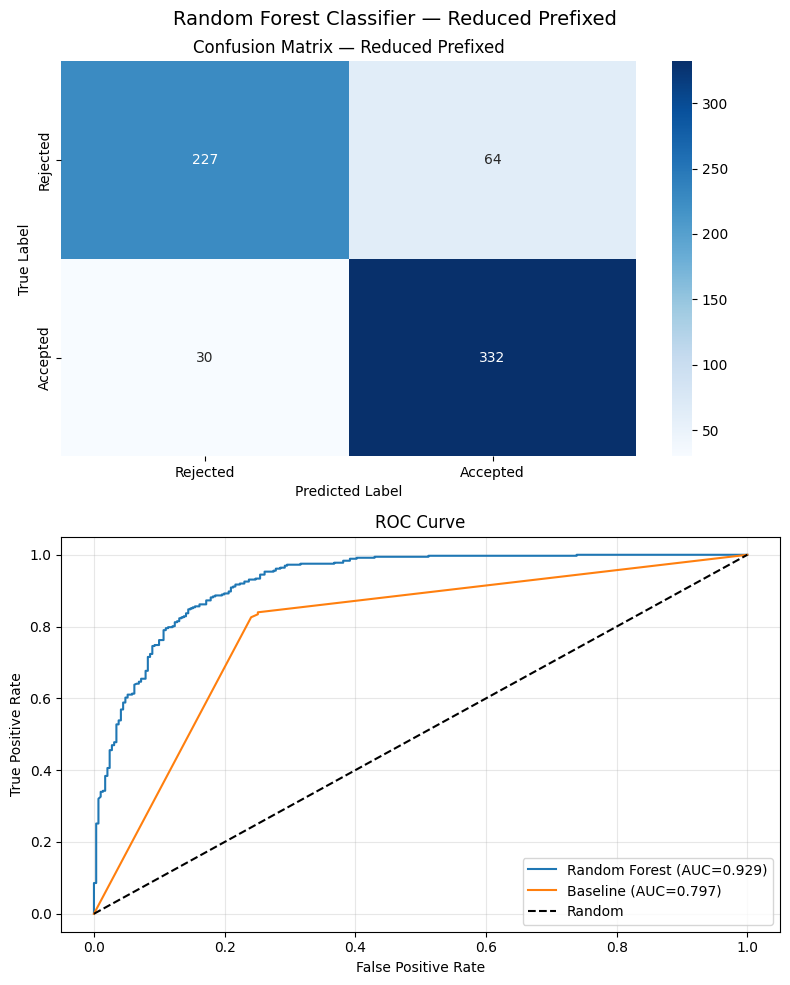


Dataset: Full Stripped
Train size: 2612  Test size: 653

── Baseline Single Decision Tree ─────────────────────────
Accuracy:  0.7994
Precision: 0.8291
Recall:    0.8039
F1:        0.8163
ROC-AUC:   0.7988

── Random Forest Classifier Results ──────────────────────
Best CV ROC-AUC: 0.9412
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.1
  max_depth: 20
  bootstrap: True
Accuracy:  0.8622  (baseline: 0.7994)
Precision: 0.8452  (baseline: 0.8291)
Recall:    0.9199  (baseline: 0.8039)
F1:        0.8810  (baseline: 0.8163)
ROC-AUC:   0.9359  (baseline: 0.7988)

── Classification Report ────────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.89      0.79      0.84       291
    Accepted       0.85      0.92      0.88       362

    accuracy                           0.86       653
   macro avg       0.87      0.86      0.86       653
weighted avg       0.86      0.86      0.86       653



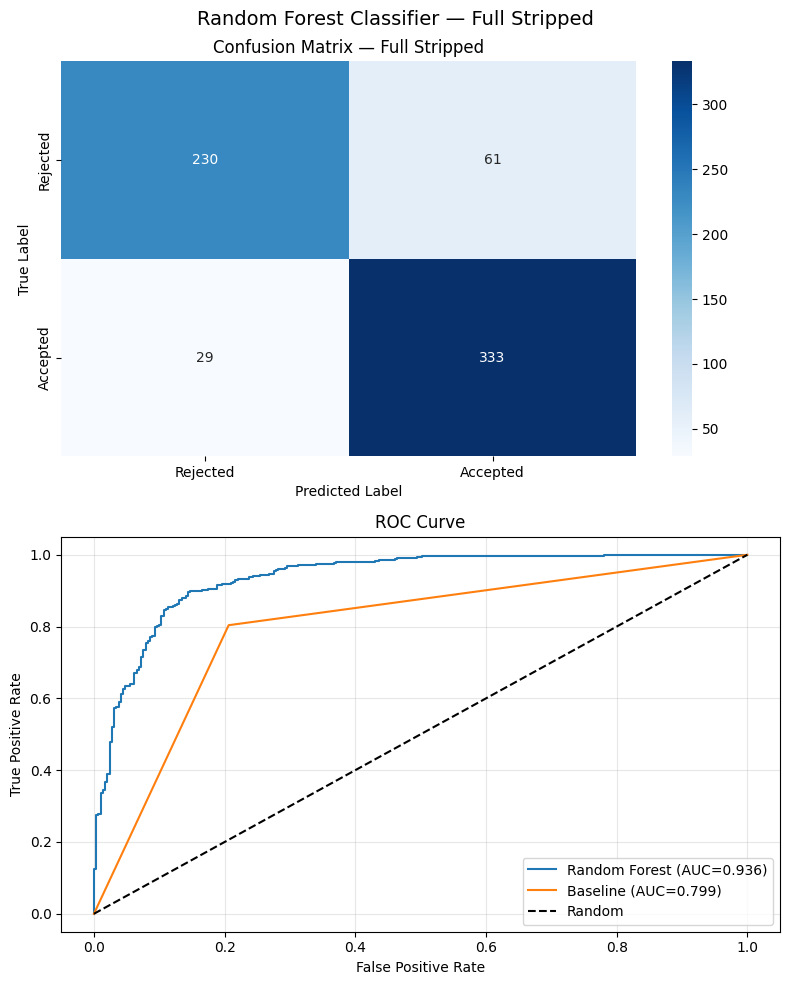


Dataset: Full Prefixed
Train size: 2612  Test size: 653

── Baseline Single Decision Tree ─────────────────────────
Accuracy:  0.8040
Precision: 0.8250
Recall:    0.8204
F1:        0.8227
ROC-AUC:   0.8020

── Random Forest Classifier Results ──────────────────────
Best CV ROC-AUC: 0.9396
  n_estimators: 100
  min_samples_split: 10
  min_samples_leaf: 1
  max_features: 0.1
  max_depth: 20
  bootstrap: True
Accuracy:  0.8606  (baseline: 0.8040)
Precision: 0.8379  (baseline: 0.8250)
Recall:    0.9282  (baseline: 0.8204)
F1:        0.8807  (baseline: 0.8227)
ROC-AUC:   0.9365  (baseline: 0.8020)

── Classification Report ────────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.90      0.78      0.83       291
    Accepted       0.84      0.93      0.88       362

    accuracy                           0.86       653
   macro avg       0.87      0.85      0.86       653
weighted avg       0.86      0.86      0.86       653



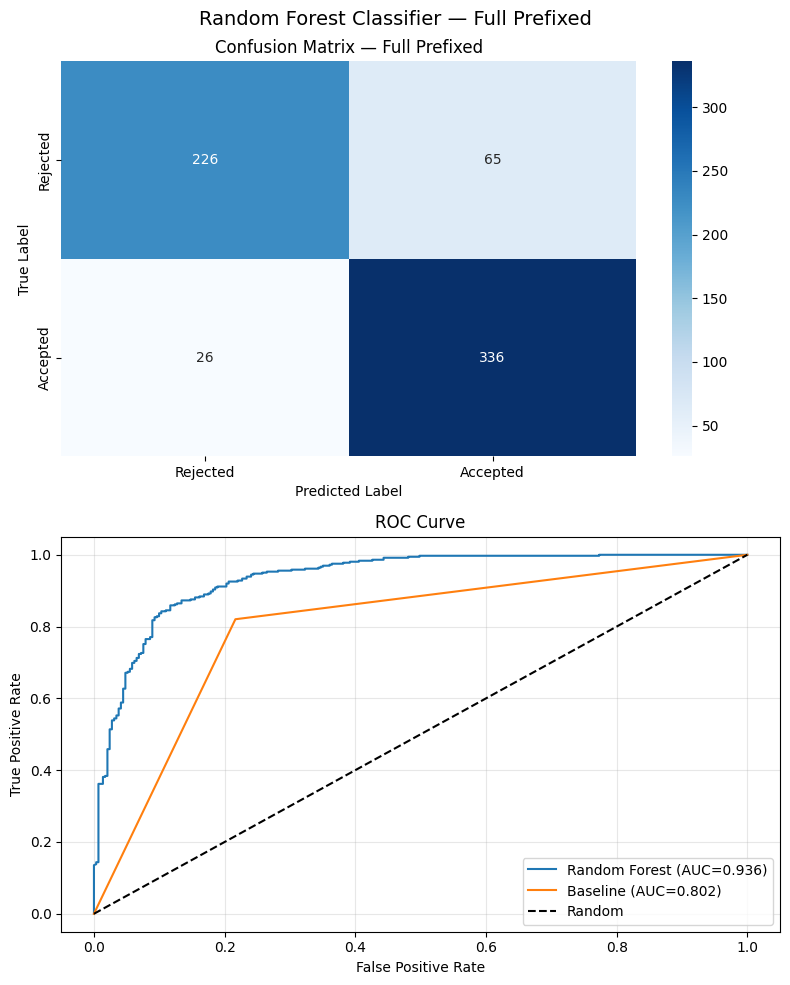

In [34]:
rf_results = {}

for name in datasets.keys():
    split = splits[name]
    _, metrics = run_random_forest_classification(
        X_train=split['X_train'],
        X_test=split['X_test'],
        y_train=split['y_train'],
        y_test=split['y_test'],
        dataset_name=name,
        cv=cv
    )
    rf_results[name] = metrics

### Prikaz rezultata:

In [40]:
summary_rf = pd.DataFrame([
    {
        'Dataset': name,
        'CV ROC-AUC': res['cv_roc_auc'],
        'Test ROC-AUC': res['test_roc_auc'],
        'Test Accuracy': res['test_accuracy'],
        'Best Params': res['best_params']
    }
    for name, res in rf_results.items()
])
display(summary_rf)

,Dataset,CV ROC-AUC,Test ROC-AUC,Test Accuracy,Best Params
0,Reduced Stripped,0.938668,0.940499,0.859112,"{'n_estimators': 100, 'min_samples_split': 10,..."
1,Reduced Prefixed,0.939243,0.928618,0.856049,"{'n_estimators': 100, 'min_samples_split': 10,..."
2,Full Stripped,0.941172,0.935932,0.862175,"{'n_estimators': 100, 'min_samples_split': 10,..."
3,Full Prefixed,0.939559,0.936497,0.860643,"{'n_estimators': 100, 'min_samples_split': 10,..."


## Algoritam 3: Xgboost
### Pravimo funkciju koja trenira i testira Xgboost klasifikator nad datim skupom podataka.

In [41]:
def run_xgboost_classification_val(X_train, X_test, y_train, y_test, dataset_name, n_trials=50):
    
    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")
    print(f"Full train size: {X_train.shape[0]}  Test size: {X_test.shape[0]}")

    X_opt, X_val, y_opt, y_val = train_test_split(
        X_train, y_train, test_size=0.2, random_state=8, stratify=y_train
    )
    print(f"Optimisation train: {X_opt.shape[0]}  Validation: {X_val.shape[0]}")

    neg = (y_opt == 0).sum()
    pos = (y_opt == 1).sum()
    spw = neg / pos

    baseline_xgb = xgb.XGBClassifier(
        n_estimators=100,
        objective="binary:logistic",
        eval_metric="auc",
        scale_pos_weight=spw,
        n_jobs=-1,
        random_state=8
    )
    baseline_xgb.fit(X_opt, y_opt)
    baseline_preds = baseline_xgb.predict(X_test)
    baseline_proba = baseline_xgb.predict_proba(X_test)[:, 1]

    print("\n── Baseline XGBoost (defaults, n=100) ───────────────")
    print(f"Accuracy:  {accuracy_score(y_test, baseline_preds):.4f}")
    print(f"F1:        {f1_score(y_test, baseline_preds):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, baseline_proba):.4f}")

    space = {
        'n_estimators':     hp.quniform('n_estimators',     100,  400,  50),
        'learning_rate':    hp.loguniform('learning_rate',  np.log(0.01), np.log(0.2)),
        'max_depth':        hp.quniform('max_depth',        2,    8,    1),
        'subsample':        hp.uniform('subsample',         0.5,  1.0),
        'colsample_bytree': hp.uniform('colsample_bytree',  0.4,  1.0),
        'min_child_weight': hp.quniform('min_child_weight', 1,    10,   1),
        'gamma':            hp.uniform('gamma',             0,    5),
        'reg_alpha': hp.loguniform('reg_alpha', np.log(1e-2), np.log(5)),
        'reg_lambda': hp.loguniform('reg_lambda', np.log(1e-2), np.log(5))
    }

    trial_counter = [0]

    def objective(params):
        params['n_estimators']     = int(params['n_estimators'])
        params['max_depth']        = int(params['max_depth'])
        params['min_child_weight'] = int(params['min_child_weight'])

        model = xgb.XGBClassifier(
            objective='binary:logistic',
            eval_metric='auc',
            scale_pos_weight=spw,
            random_state=8,
            n_jobs=-1,
            early_stopping_rounds=20,
            **params
        )
        model.fit(
            X_opt, y_opt,
            eval_set=[(X_val, y_val)],
            verbose=False
        )
        proba = model.predict_proba(X_val)[:, 1]
        auc = roc_auc_score(y_val, proba)

        trial_counter[0] += 1
        if trial_counter[0] % 10 == 0:
            print(f"  Trial {trial_counter[0]:>3}  Val AUC={auc:.4f}")

        return {'loss': -auc, 'status': STATUS_OK, 'val_auc': auc, 'params': params}

    trials = Trials()
    print(f"\nRunning Bayesian optimisation ({n_trials} trials, validation set):")
    best_raw = fmin(
        fn=objective,
        space=space,
        algo=tpe.suggest,
        max_evals=n_trials,
        trials=trials,
        rstate=np.random.default_rng(8),
        verbose=False
    )

    best_params = space_eval(space, best_raw)
    best_params['n_estimators']     = int(best_params['n_estimators'])
    best_params['max_depth']        = int(best_params['max_depth'])
    best_params['min_child_weight'] = int(best_params['min_child_weight'])

    best_val_auc = -min(t['result']['loss'] for t in trials.trials
                        if t['result']['status'] == STATUS_OK)

    print(f"\nBest validation AUC: {best_val_auc:.4f}")
    print("Best parameters:")
    for k, v in best_params.items():
        print(f"  {k:>5}: {v}")

    final_xgb = xgb.XGBClassifier(
        objective='binary:logistic',
        eval_metric='auc',
        scale_pos_weight=spw,
        random_state=8,
        n_jobs=-1,
        early_stopping_rounds=20,
        **best_params
    )
    final_xgb.fit(
        X_opt, y_opt,
        eval_set=[(X_val, y_val)],
        verbose=False
    )

    y_pred = final_xgb.predict(X_test)
    y_proba = final_xgb.predict_proba(X_test)[:, 1]

    print(f"\n── Tuned XGBoost vs Baseline ───────────────────────────")
    print(f"{'':12}  {'Tuned XGB':>10}  {'Baseline':>10}")
    print(f"{'Accuracy':12}  {accuracy_score(y_test, y_pred):>10.4f}  "
          f"{accuracy_score(y_test, baseline_preds):>10.4f}")
    print(f"{'Precision':12}  {precision_score(y_test, y_pred):>10.4f}  "
          f"{precision_score(y_test, baseline_preds):>10.4f}")
    print(f"{'Recall':12}  {recall_score(y_test, y_pred):>10.4f}  "
          f"{recall_score(y_test, baseline_preds):>10.4f}")
    print(f"{'F1':12}  {f1_score(y_test, y_pred):>10.4f}  "
          f"{f1_score(y_test, baseline_preds):>10.4f}")
    print(f"{'ROC-AUC':12}  {roc_auc_score(y_test, y_proba):>10.4f}  "
          f"{roc_auc_score(y_test, baseline_proba):>10.4f}")

    print("\n── Classification Report ──────────────────────────────")
    print(classification_report(y_test, y_pred,
                                target_names=['Rejected', 'Accepted']))

    fig, axes = plt.subplots(2, 1, figsize=(7, 15))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Rejected', 'Accepted'],
                yticklabels=['Rejected', 'Accepted'])
    axes[0].set_title(f'Confusion Matrix — {dataset_name}')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    fpr_xgb,  tpr_xgb,  _ = roc_curve(y_test, y_proba)
    fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
    axes[1].plot(fpr_xgb,  tpr_xgb,
                 label=f'Tuned XGB (AUC={roc_auc_score(y_test, y_proba):.3f})')
    axes[1].plot(fpr_base, tpr_base,
                 label=f'Baseline  (AUC={roc_auc_score(y_test, baseline_proba):.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'XGBoost — Validation‑Based Tuning ({dataset_name})', fontsize=14)
    plt.tight_layout()
    plt.show()

    metrics = {
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_proba),
        'val_roc_auc': best_val_auc,
        'best_params': best_params
    }
    return final_xgb, metrics


Dataset: Reduced Stripped
Full train size: 2612  Test size: 653
Optimisation train: 2089  Validation: 523

── Baseline XGBoost (defaults, n=100) ───────────────
Accuracy:  0.8698
F1:        0.8862
ROC-AUC:   0.9421

Running Bayesian optimisation (40 trials, validation set):
  Trial  10  Val AUC=0.9325
  Trial  20  Val AUC=0.9390
  Trial  30  Val AUC=0.9379
  Trial  40  Val AUC=0.9460

Best validation AUC: 0.9506
Best parameters:
  colsample_bytree: 0.7113383530039588
  gamma: 0.8144236088917239
  learning_rate: 0.06141601388646946
  max_depth: 7
  min_child_weight: 9
  n_estimators: 250
  reg_alpha: 2.8630409073255967
  reg_lambda: 0.2585865826952759
  subsample: 0.8343169106015511

── Tuned XGBoost vs Baseline ───────────────────────────
               Tuned XGB    Baseline
Accuracy          0.8622      0.8698
Precision         0.8523      0.8597
Recall            0.9088      0.9144
F1                0.8797      0.8862
ROC-AUC           0.9357      0.9421

── Classification Report ──

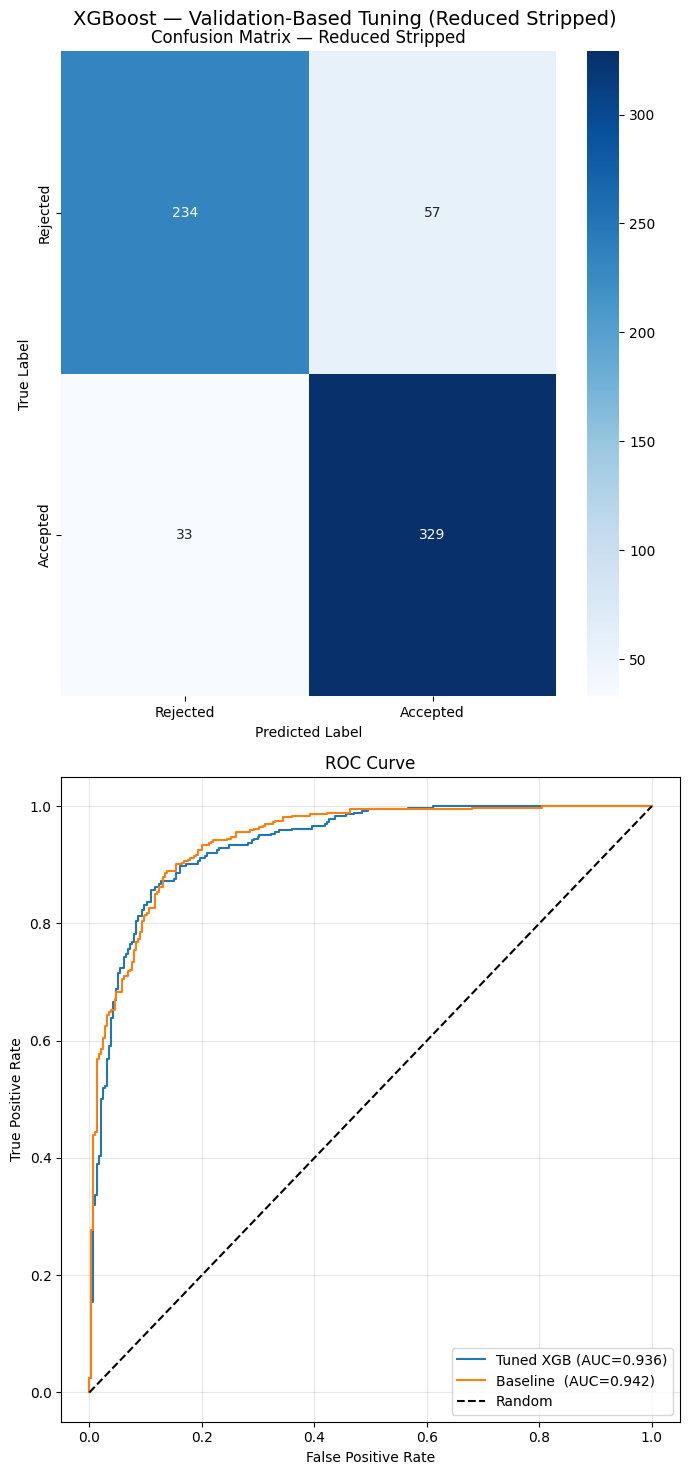


Dataset: Reduced Prefixed
Full train size: 2612  Test size: 653
Optimisation train: 2089  Validation: 523

── Baseline XGBoost (defaults, n=100) ───────────────
Accuracy:  0.8652
F1:        0.8808
ROC-AUC:   0.9310

Running Bayesian optimisation (40 trials, validation set):
  Trial  10  Val AUC=0.9363
  Trial  20  Val AUC=0.9376
  Trial  30  Val AUC=0.9332
  Trial  40  Val AUC=0.9335

Best validation AUC: 0.9465
Best parameters:
  colsample_bytree: 0.5977688781103858
  gamma: 1.1977217041865078
  learning_rate: 0.04806736567697824
  max_depth: 7
  min_child_weight: 6
  n_estimators: 300
  reg_alpha: 0.07429571218532603
  reg_lambda: 3.46553517522255
  subsample: 0.8246660970710218

── Tuned XGBoost vs Baseline ───────────────────────────
               Tuned XGB    Baseline
Accuracy          0.8606      0.8652
Precision         0.8556      0.8644
Recall            0.9006      0.8978
F1                0.8775      0.8808
ROC-AUC           0.9281      0.9310

── Classification Report ───

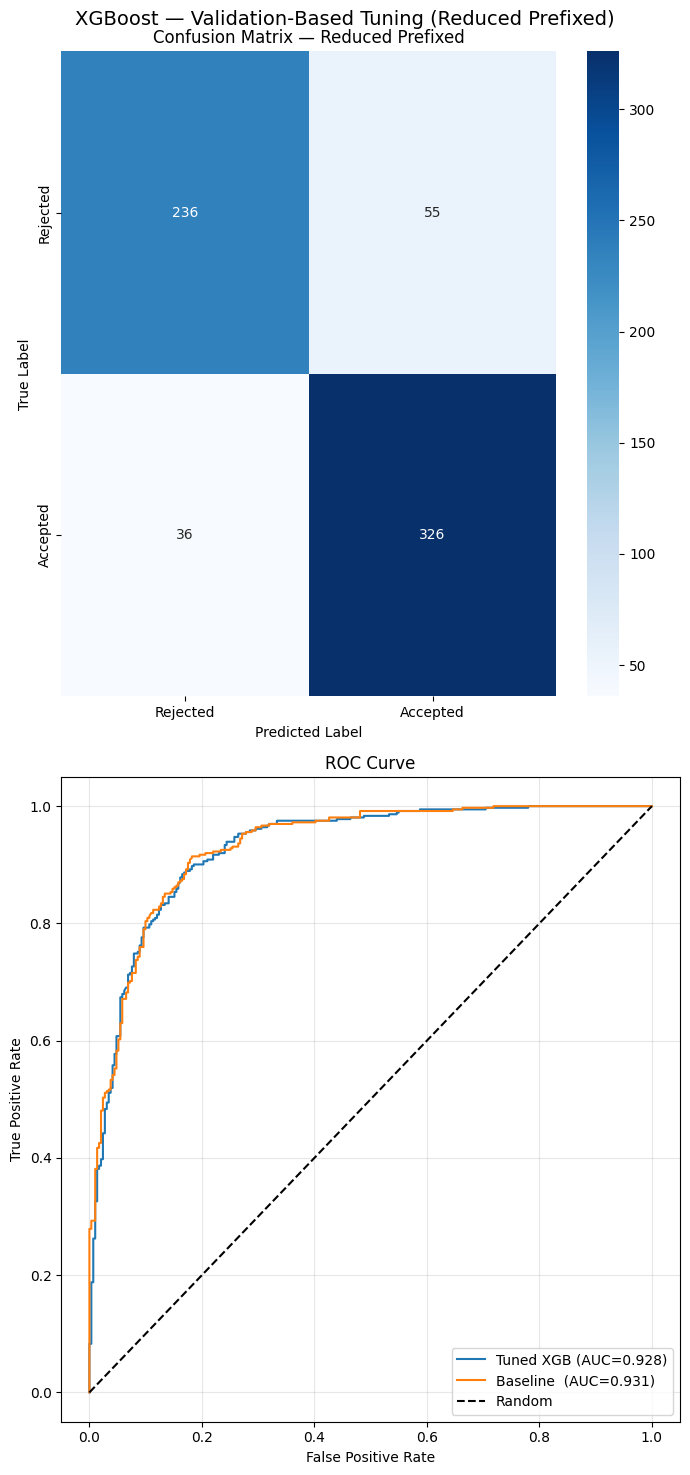


Dataset: Full Stripped
Full train size: 2612  Test size: 653
Optimisation train: 2089  Validation: 523

── Baseline XGBoost (defaults, n=100) ───────────────
Accuracy:  0.8668
F1:        0.8823
ROC-AUC:   0.9342

Running Bayesian optimisation (40 trials, validation set):
  Trial  10  Val AUC=0.9270
  Trial  20  Val AUC=0.9326
  Trial  30  Val AUC=0.9354
  Trial  40  Val AUC=0.9275

Best validation AUC: 0.9392
Best parameters:
  colsample_bytree: 0.4165024268972626
  gamma: 0.12033440814017504
  learning_rate: 0.035283612774513355
  max_depth: 8
  min_child_weight: 7
  n_estimators: 150
  reg_alpha: 0.07958761039679901
  reg_lambda: 3.2029741347007636
  subsample: 0.9996980603562872

── Tuned XGBoost vs Baseline ───────────────────────────
               Tuned XGB    Baseline
Accuracy          0.8683      0.8668
Precision         0.8557      0.8647
Recall            0.9171      0.9006
F1                0.8853      0.8823
ROC-AUC           0.9272      0.9342

── Classification Report ──

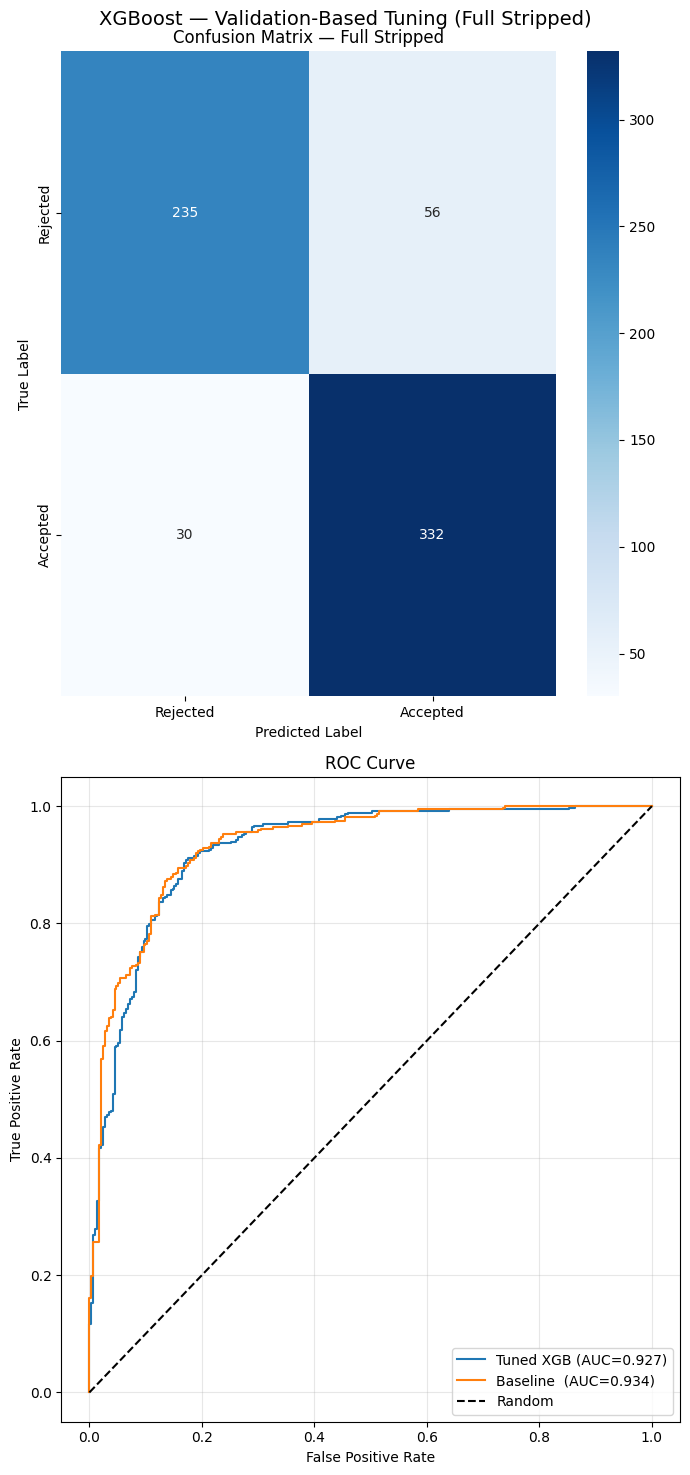


Dataset: Full Prefixed
Full train size: 2612  Test size: 653
Optimisation train: 2089  Validation: 523

── Baseline XGBoost (defaults, n=100) ───────────────
Accuracy:  0.8683
F1:        0.8835
ROC-AUC:   0.9323

Running Bayesian optimisation (40 trials, validation set):
  Trial  10  Val AUC=0.9201
  Trial  20  Val AUC=0.9250
  Trial  30  Val AUC=0.9371
  Trial  40  Val AUC=0.9388

Best validation AUC: 0.9423
Best parameters:
  colsample_bytree: 0.5329080833357802
  gamma: 0.6625620549884059
  learning_rate: 0.07761959668627946
  max_depth: 6
  min_child_weight: 8
  n_estimators: 100
  reg_alpha: 0.06599960171693621
  reg_lambda: 1.0174791678041668
  subsample: 0.989298044040845

── Tuned XGBoost vs Baseline ───────────────────────────
               Tuned XGB    Baseline
Accuracy          0.8668      0.8683
Precision         0.8686      0.8670
Recall            0.8950      0.9006
F1                0.8816      0.8835
ROC-AUC           0.9336      0.9323

── Classification Report ─────

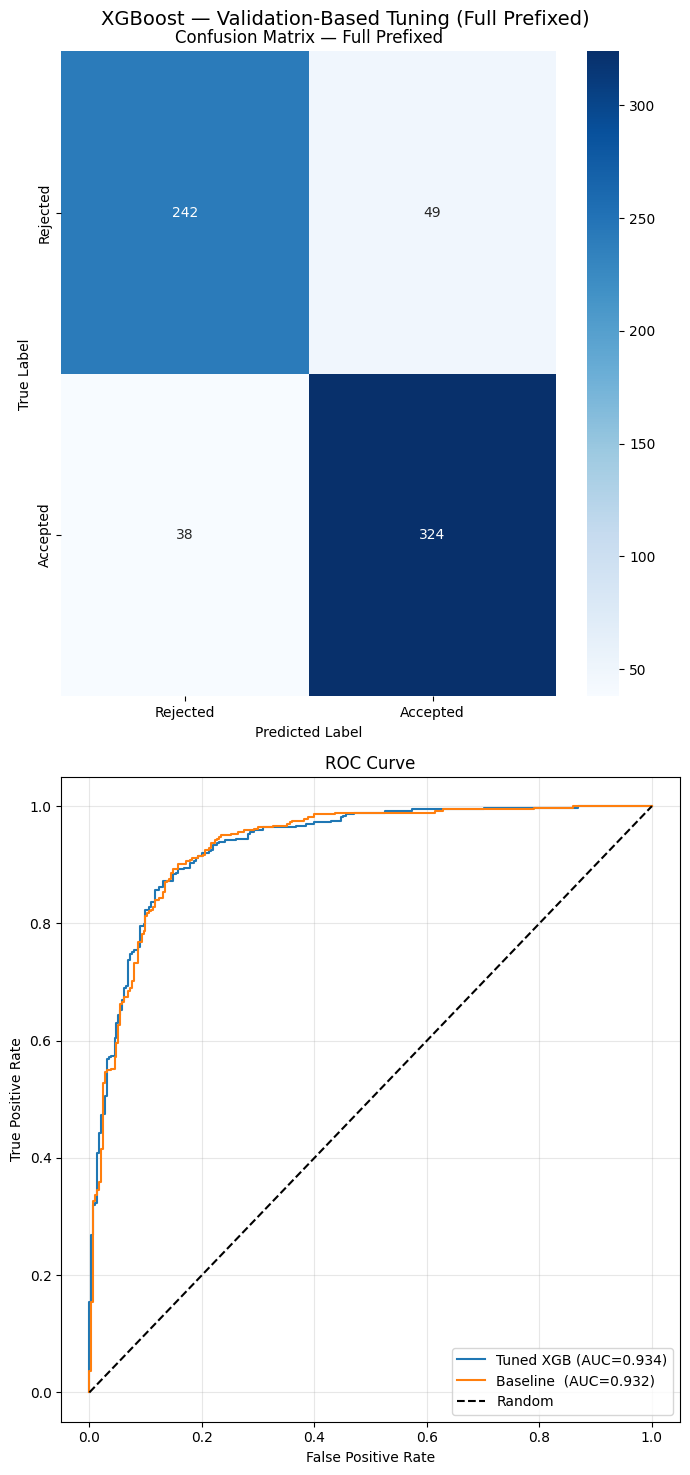

In [42]:
xgb_results = {}

for name in datasets.keys():
    split = splits[name]
    _, metrics = run_xgboost_classification_val(
        X_train=split['X_train'],
        X_test=split['X_test'],
        y_train=split['y_train'],
        y_test=split['y_test'],
        dataset_name=name,
        n_trials=40
    )
    xgb_results[name] = metrics

In [43]:
def run_svm_classification(X_train, X_test, y_train, y_test, dataset_name, n_iter=50):

    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")
    print(f"Train size: {X_train.shape[0]}  Test size: {X_test.shape[0]}")

    baseline_svm = SGDClassifier(loss='hinge', random_state=8, n_jobs=-1)
    baseline_svm.fit(X_train, y_train)
    baseline_preds = baseline_svm.predict(X_test)
    baseline_scores = baseline_svm.decision_function(X_test)   # for ROC-AUC

    print("\n── Baseline Linear SVM (defaults) ─────────────────────")
    print(f"Accuracy:  {accuracy_score(y_test, baseline_preds):.4f}")
    print(f"Precision: {precision_score(y_test, baseline_preds):.4f}")
    print(f"Recall:    {recall_score(y_test, baseline_preds):.4f}")
    print(f"F1:        {f1_score(y_test, baseline_preds):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, baseline_scores):.4f}")

    param_dist = {
        'alpha': loguniform(1e-6, 1e2),
        'penalty': ['elasticnet'],
        'l1_ratio': np.linspace(0, 1, 11),
    }

    svm_model = SGDClassifier(loss='hinge', random_state=8, n_jobs=-1)
    random_search = RandomizedSearchCV(
        svm_model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=0,
        random_state=8,
        n_jobs=-1
    )
    print("\nTuning SVM (RandomizedSearchCV)...")
    random_search.fit(X_train, y_train)

    best_svm = random_search.best_estimator_
    y_pred = best_svm.predict(X_test)
    y_scores = best_svm.decision_function(X_test)

    print(f"\n── Tuned SVM vs Baseline ───────────────────────────────")
    print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
    print("Best parameters:")
    for k, v in random_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}  (baseline: {accuracy_score(y_test, baseline_preds):.4f})")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}  (baseline: {precision_score(y_test, baseline_preds):.4f})")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}  (baseline: {recall_score(y_test, baseline_preds):.4f})")
    print(f"F1:        {f1_score(y_test, y_pred):.4f}  (baseline: {f1_score(y_test, baseline_preds):.4f})")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_scores):.4f}  (baseline: {roc_auc_score(y_test, baseline_scores):.4f})")

    print("\n── Classification Report ──────────────────────────────")
    print(classification_report(y_test, y_pred,
                                target_names=['Rejected', 'Accepted']))

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Rejected', 'Accepted'],
                yticklabels=['Rejected', 'Accepted'])
    axes[0].set_title(f'Confusion Matrix — {dataset_name}')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    fpr_svm, tpr_svm, _ = roc_curve(y_test, y_scores)
    fpr_base, tpr_base, _ = roc_curve(y_test, baseline_scores)
    axes[1].plot(fpr_svm, tpr_svm,
                 label=f'Tuned SVM (AUC={roc_auc_score(y_test, y_scores):.3f})')
    axes[1].plot(fpr_base, tpr_base,
                 label=f'Baseline (AUC={roc_auc_score(y_test, baseline_scores):.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'SVM Classifier — {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    metrics = {
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_scores),
        'cv_roc_auc': random_search.best_score_,
        'best_params': random_search.best_params_
    }
    return best_svm, metrics


Dataset: Reduced Stripped
Train size: 2612  Test size: 653

── Baseline Linear SVM (defaults) ─────────────────────
Accuracy:  0.8821
Precision: 0.8760
Recall:    0.9171
F1:        0.8961
ROC-AUC:   0.9356

Tuning SVM (RandomizedSearchCV)...

── Tuned SVM vs Baseline ───────────────────────────────
Best CV ROC-AUC: 0.9388
Best parameters:
  alpha: 0.00028259654839291623
  l1_ratio: 0.30000000000000004
  penalty: elasticnet
Accuracy:  0.8928  (baseline: 0.8821)
Precision: 0.8989  (baseline: 0.8760)
Recall:    0.9088  (baseline: 0.9171)
F1:        0.9038  (baseline: 0.8961)
ROC-AUC:   0.9412  (baseline: 0.9356)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.89      0.87      0.88       291
    Accepted       0.90      0.91      0.90       362

    accuracy                           0.89       653
   macro avg       0.89      0.89      0.89       653
weighted avg       0.89      0.89      0.89       653

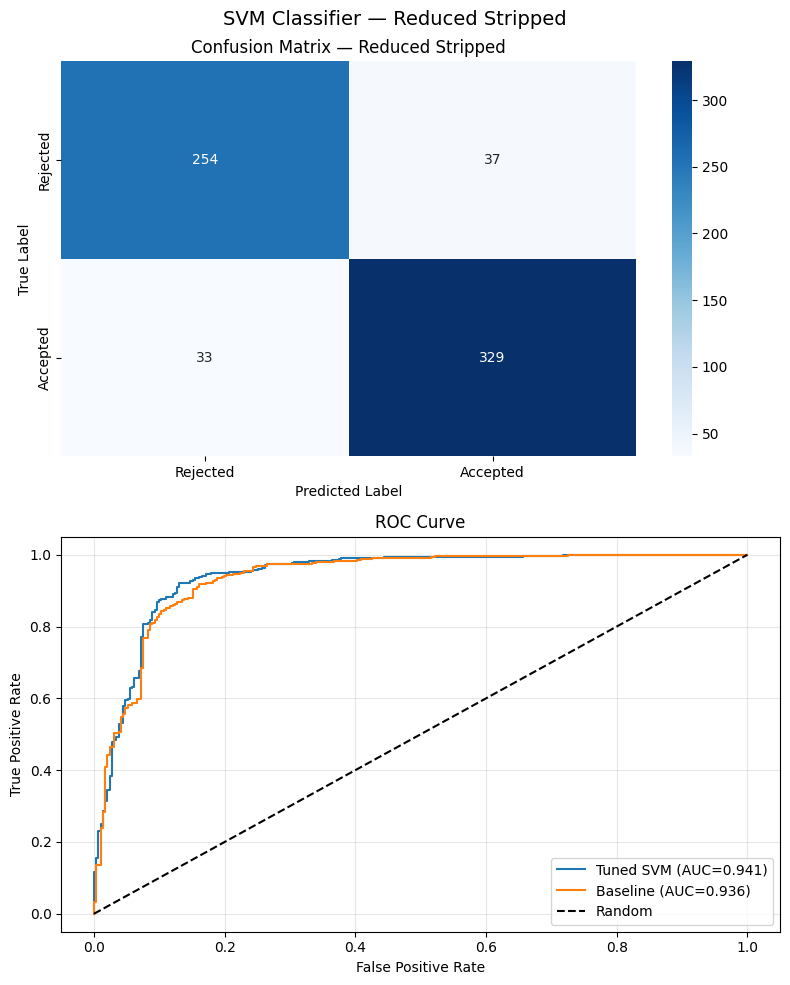


Dataset: Reduced Prefixed
Train size: 2612  Test size: 653

── Baseline Linear SVM (defaults) ─────────────────────
Accuracy:  0.8729
Precision: 0.8720
Recall:    0.9033
F1:        0.8874
ROC-AUC:   0.9340

Tuning SVM (RandomizedSearchCV)...

── Tuned SVM vs Baseline ───────────────────────────────
Best CV ROC-AUC: 0.9323
Best parameters:
  alpha: 0.0009854988232926578
  l1_ratio: 1.0
  penalty: elasticnet
Accuracy:  0.8729  (baseline: 0.8729)
Precision: 0.8700  (baseline: 0.8720)
Recall:    0.9061  (baseline: 0.9033)
F1:        0.8877  (baseline: 0.8874)
ROC-AUC:   0.9329  (baseline: 0.9340)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.88      0.83      0.85       291
    Accepted       0.87      0.91      0.89       362

    accuracy                           0.87       653
   macro avg       0.87      0.87      0.87       653
weighted avg       0.87      0.87      0.87       653



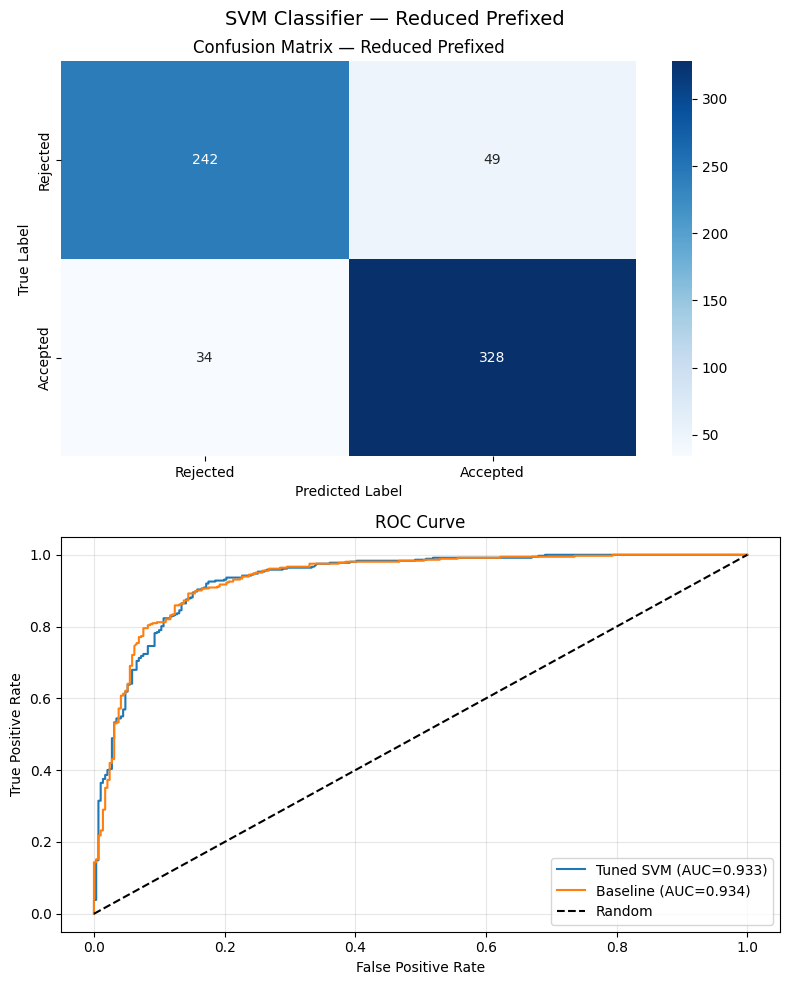


Dataset: Full Stripped
Train size: 2612  Test size: 653

── Baseline Linear SVM (defaults) ─────────────────────
Accuracy:  0.8760
Precision: 0.8727
Recall:    0.9088
F1:        0.8904
ROC-AUC:   0.9321

Tuning SVM (RandomizedSearchCV)...

── Tuned SVM vs Baseline ───────────────────────────────
Best CV ROC-AUC: 0.9466
Best parameters:
  alpha: 0.00028259654839291623
  l1_ratio: 0.30000000000000004
  penalty: elasticnet
Accuracy:  0.9066  (baseline: 0.8760)
Precision: 0.9079  (baseline: 0.8727)
Recall:    0.9254  (baseline: 0.9088)
F1:        0.9166  (baseline: 0.8904)
ROC-AUC:   0.9445  (baseline: 0.9321)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.90      0.88      0.89       291
    Accepted       0.91      0.93      0.92       362

    accuracy                           0.91       653
   macro avg       0.91      0.90      0.91       653
weighted avg       0.91      0.91      0.91       653



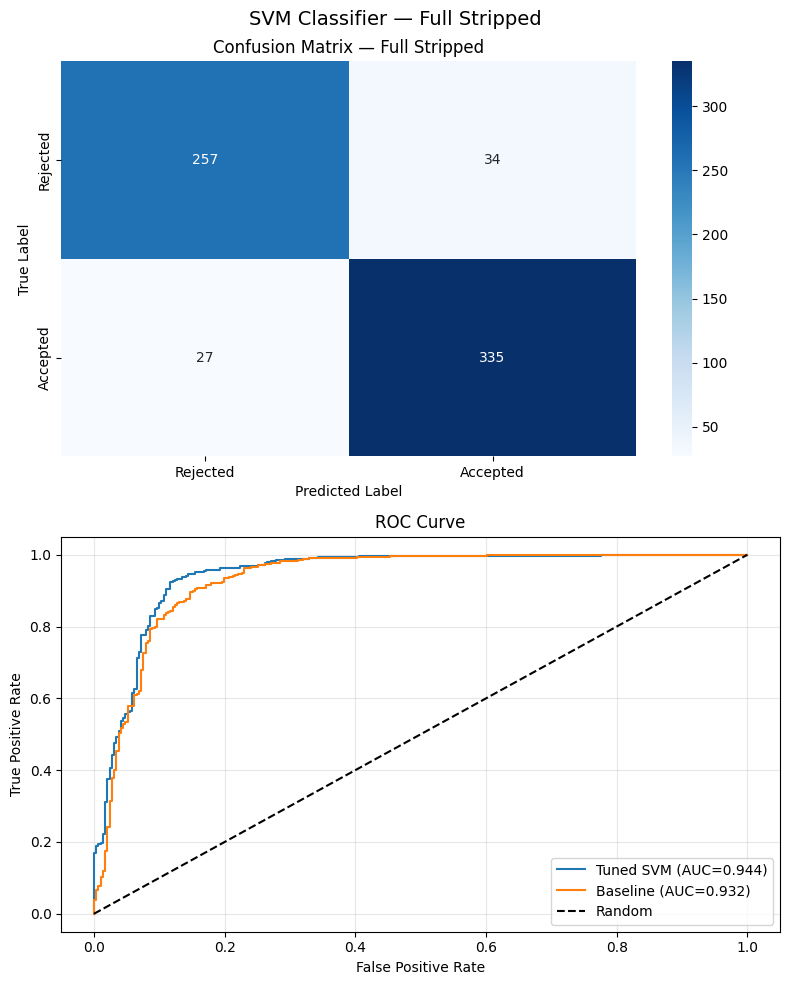


Dataset: Full Prefixed
Train size: 2612  Test size: 653

── Baseline Linear SVM (defaults) ─────────────────────
Accuracy:  0.8576
Precision: 0.8665
Recall:    0.8785
F1:        0.8724
ROC-AUC:   0.9329

Tuning SVM (RandomizedSearchCV)...

── Tuned SVM vs Baseline ───────────────────────────────
Best CV ROC-AUC: 0.9398
Best parameters:
  alpha: 0.00028259654839291623
  l1_ratio: 0.30000000000000004
  penalty: elasticnet
Accuracy:  0.8913  (baseline: 0.8576)
Precision: 0.8880  (baseline: 0.8665)
Recall:    0.9199  (baseline: 0.8785)
F1:        0.9037  (baseline: 0.8724)
ROC-AUC:   0.9457  (baseline: 0.9329)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.90      0.86      0.88       291
    Accepted       0.89      0.92      0.90       362

    accuracy                           0.89       653
   macro avg       0.89      0.89      0.89       653
weighted avg       0.89      0.89      0.89       653



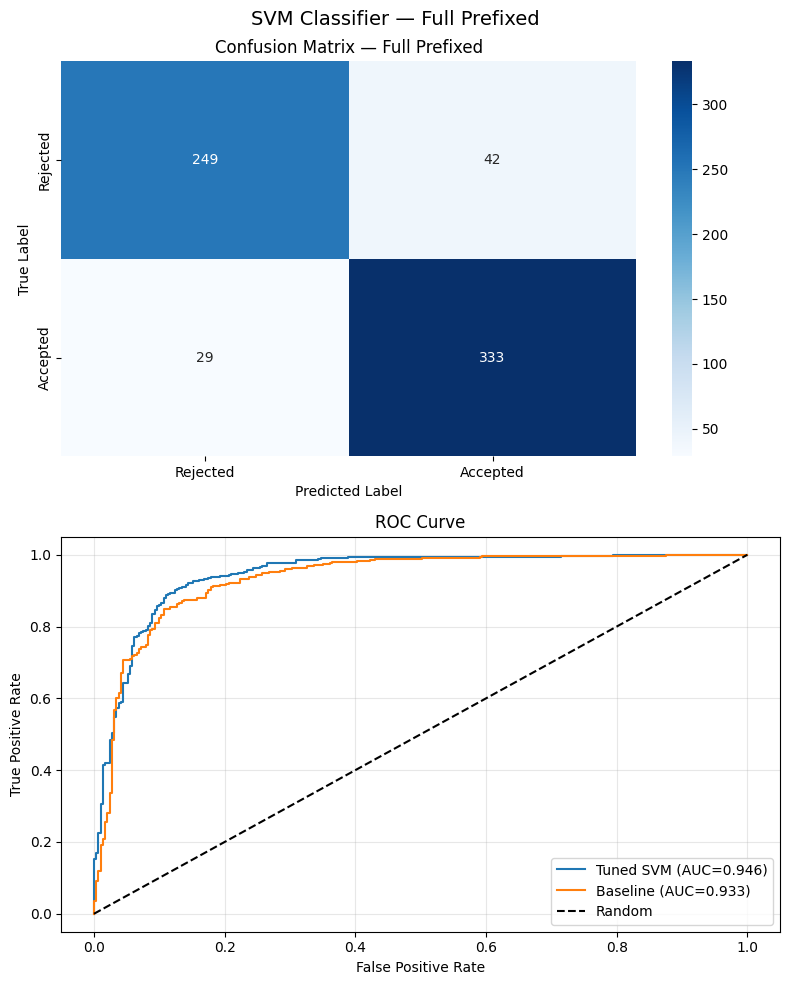

In [44]:
svm_results = {}

for name in datasets.keys():
    split = splits[name]
    _, metrics = run_svm_classification(
        X_train=split['X_train'],
        X_test=split['X_test'],
        y_train=split['y_train'],
        y_test=split['y_test'],
        dataset_name=name,
        n_iter=50 
    )
    svm_results[name] = metrics

In [45]:
summary_svm = pd.DataFrame([
    {
        'Dataset': name,
        'CV ROC-AUC': res['cv_roc_auc'],
        'Test ROC-AUC': res['test_roc_auc'],
        'Test Accuracy': res['test_accuracy'],
        'Best Params': res['best_params']
    }
    for name, res in svm_results.items()
])
display(summary_svm)

,Dataset,CV ROC-AUC,Test ROC-AUC,Test Accuracy,Best Params
0,Reduced Stripped,0.938817,0.941163,0.892802,"{'alpha': 0.00028259654839291623, 'l1_ratio': ..."
1,Reduced Prefixed,0.932324,0.932937,0.872894,"{'alpha': 0.0009854988232926578, 'l1_ratio': 1..."
2,Full Stripped,0.946566,0.944457,0.906585,"{'alpha': 0.00028259654839291623, 'l1_ratio': ..."
3,Full Prefixed,0.939829,0.945682,0.891271,"{'alpha': 0.00028259654839291623, 'l1_ratio': ..."


In [46]:
def run_logistic_regression_classification(X_train, X_test, y_train, y_test, dataset_name, n_iter=50):

    print(f"\n{'='*70}")
    print(f"Dataset: {dataset_name}")
    print(f"{'='*70}")
    print(f"Train size: {X_train.shape[0]}  Test size: {X_test.shape[0]}")

    baseline_lr = SGDClassifier(loss='log_loss', random_state=8, n_jobs=-1)
    baseline_lr.fit(X_train, y_train)
    baseline_preds = baseline_lr.predict(X_test)
    baseline_proba = baseline_lr.predict_proba(X_test)[:, 1]

    print("\n── Baseline Logistic Regression (defaults) ────────────")
    print(f"Accuracy:  {accuracy_score(y_test, baseline_preds):.4f}")
    print(f"Precision: {precision_score(y_test, baseline_preds):.4f}")
    print(f"Recall:    {recall_score(y_test, baseline_preds):.4f}")
    print(f"F1:        {f1_score(y_test, baseline_preds):.4f}")
    print(f"ROC-AUC:   {roc_auc_score(y_test, baseline_proba):.4f}")

    param_dist = {
        'alpha': loguniform(1e-6, 1e2),
        'penalty': ['elasticnet'],
        'l1_ratio': np.linspace(0, 1, 11),
    }

    lr_model = SGDClassifier(loss='log_loss', random_state=8, n_jobs=-1)
    random_search = RandomizedSearchCV(
        lr_model,
        param_distributions=param_dist,
        n_iter=n_iter,
        scoring='roc_auc',
        cv=cv,
        verbose=0,
        random_state=8,
        n_jobs=-1
    )
    print("\nTuning Logistic Regression (RandomizedSearchCV)...")
    random_search.fit(X_train, y_train)

    best_lr = random_search.best_estimator_
    y_pred = best_lr.predict(X_test)
    y_proba = best_lr.predict_proba(X_test)[:, 1]

    print(f"\n── Tuned Logistic Regression vs Baseline ──────────────")
    print(f"Best CV ROC-AUC: {random_search.best_score_:.4f}")
    print("Best parameters:")
    for k, v in random_search.best_params_.items():
        print(f"  {k}: {v}")
    print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}  (baseline: {accuracy_score(y_test, baseline_preds):.4f})")
    print(f"Precision: {precision_score(y_test, y_pred):.4f}  (baseline: {precision_score(y_test, baseline_preds):.4f})")
    print(f"Recall:    {recall_score(y_test, y_pred):.4f}  (baseline: {recall_score(y_test, baseline_preds):.4f})")
    print(f"F1:        {f1_score(y_test, y_pred):.4f}  (baseline: {f1_score(y_test, baseline_preds):.4f})")
    print(f"ROC-AUC:   {roc_auc_score(y_test, y_proba):.4f}  (baseline: {roc_auc_score(y_test, baseline_proba):.4f})")

    print("\n── Classification Report ──────────────────────────────")
    print(classification_report(y_test, y_pred,
                                target_names=['Rejected', 'Accepted']))

    fig, axes = plt.subplots(2, 1, figsize=(8, 10))

    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Rejected', 'Accepted'],
                yticklabels=['Rejected', 'Accepted'])
    axes[0].set_title(f'Confusion Matrix — {dataset_name}')
    axes[0].set_ylabel('True Label')
    axes[0].set_xlabel('Predicted Label')

    fpr_lr, tpr_lr, _ = roc_curve(y_test, y_proba)
    fpr_base, tpr_base, _ = roc_curve(y_test, baseline_proba)
    axes[1].plot(fpr_lr, tpr_lr,
                 label=f'Tuned LR (AUC={roc_auc_score(y_test, y_proba):.3f})')
    axes[1].plot(fpr_base, tpr_base,
                 label=f'Baseline (AUC={roc_auc_score(y_test, baseline_proba):.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', label='Random')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Logistic Regression — {dataset_name}', fontsize=14)
    plt.tight_layout()
    plt.show()

    metrics = {
        'test_accuracy': accuracy_score(y_test, y_pred),
        'test_roc_auc': roc_auc_score(y_test, y_proba),
        'cv_roc_auc': random_search.best_score_,
        'best_params': random_search.best_params_
    }
    return best_lr, metrics


Dataset: Reduced Stripped
Train size: 2612  Test size: 653

── Baseline Logistic Regression (defaults) ────────────
Accuracy:  0.8882
Precision: 0.8874
Recall:    0.9144
F1:        0.9007
ROC-AUC:   0.9451

Tuning Logistic Regression (RandomizedSearchCV)...

── Tuned Logistic Regression vs Baseline ──────────────
Best CV ROC-AUC: 0.9463
Best parameters:
  alpha: 0.000205399898260439
  l1_ratio: 0.5
  penalty: elasticnet
Accuracy:  0.8928  (baseline: 0.8882)
Precision: 0.8744  (baseline: 0.8874)
Recall:    0.9420  (baseline: 0.9144)
F1:        0.9069  (baseline: 0.9007)
ROC-AUC:   0.9441  (baseline: 0.9451)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.92      0.83      0.87       291
    Accepted       0.87      0.94      0.91       362

    accuracy                           0.89       653
   macro avg       0.90      0.89      0.89       653
weighted avg       0.89      0.89      0.89       653



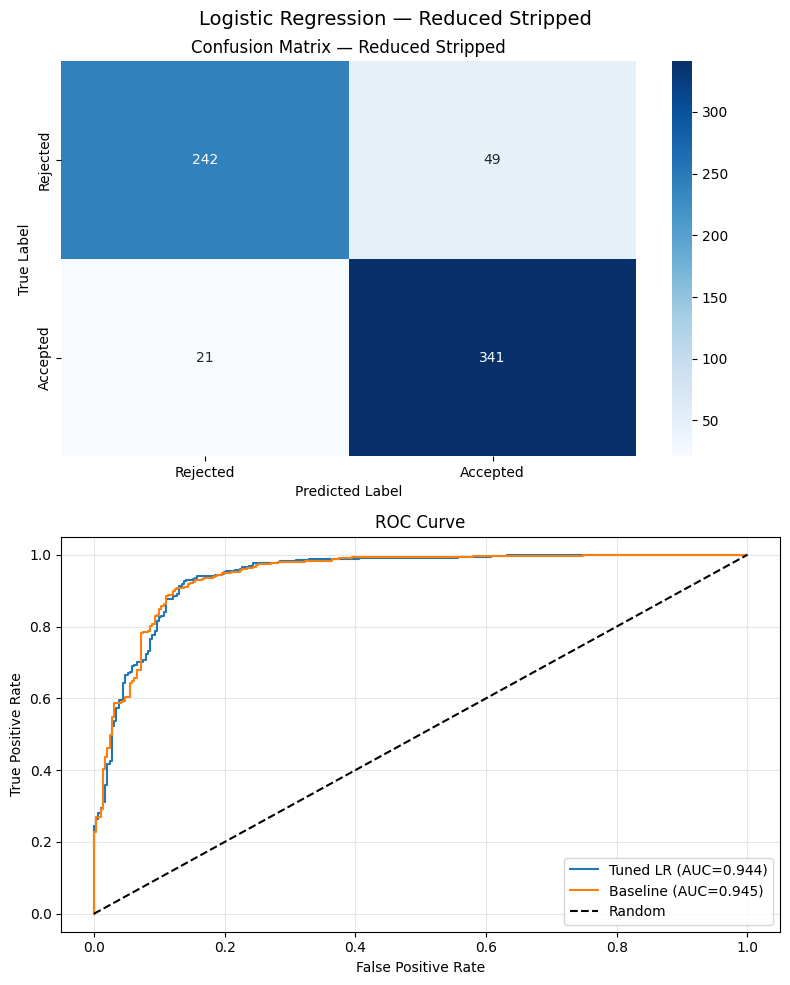


Dataset: Reduced Prefixed
Train size: 2612  Test size: 653

── Baseline Logistic Regression (defaults) ────────────
Accuracy:  0.8806
Precision: 0.8859
Recall:    0.9006
F1:        0.8932
ROC-AUC:   0.9413

Tuning Logistic Regression (RandomizedSearchCV)...

── Tuned Logistic Regression vs Baseline ──────────────
Best CV ROC-AUC: 0.9429
Best parameters:
  alpha: 0.000254064590662387
  l1_ratio: 0.1
  penalty: elasticnet
Accuracy:  0.8836  (baseline: 0.8806)
Precision: 0.8686  (baseline: 0.8859)
Recall:    0.9309  (baseline: 0.9006)
F1:        0.8987  (baseline: 0.8932)
ROC-AUC:   0.9406  (baseline: 0.9413)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.91      0.82      0.86       291
    Accepted       0.87      0.93      0.90       362

    accuracy                           0.88       653
   macro avg       0.89      0.88      0.88       653
weighted avg       0.89      0.88      0.88       653



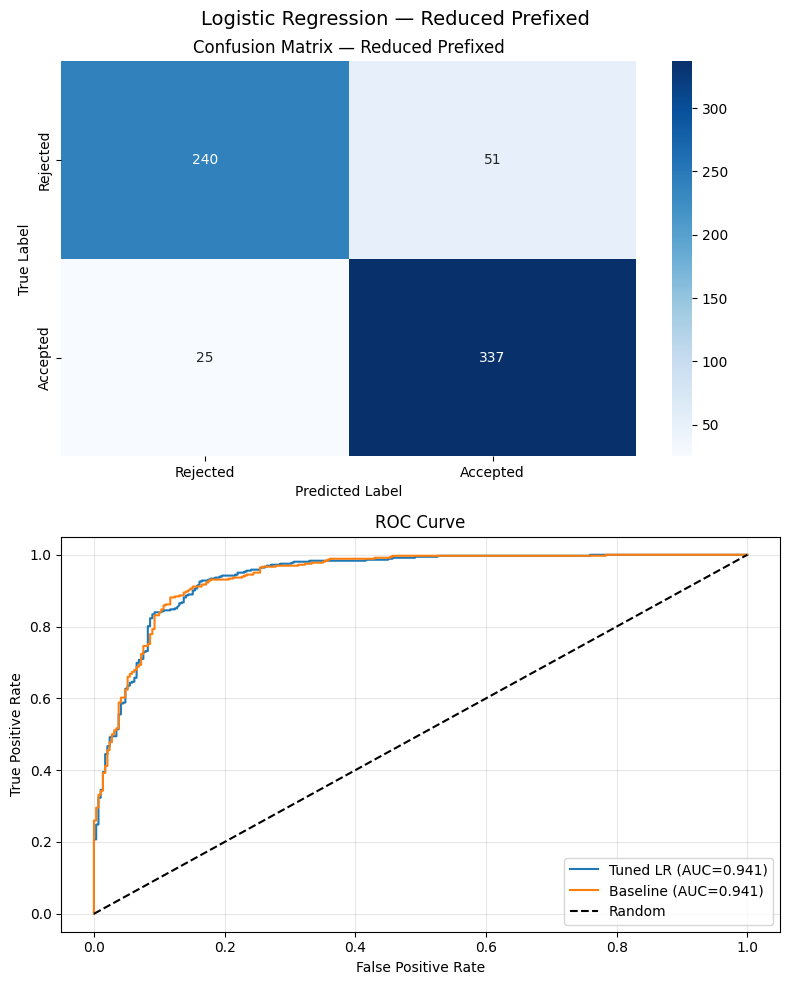


Dataset: Full Stripped
Train size: 2612  Test size: 653

── Baseline Logistic Regression (defaults) ────────────
Accuracy:  0.8882
Precision: 0.9003
Recall:    0.8978
F1:        0.8990
ROC-AUC:   0.9503

Tuning Logistic Regression (RandomizedSearchCV)...

── Tuned Logistic Regression vs Baseline ──────────────
Best CV ROC-AUC: 0.9523
Best parameters:
  alpha: 0.00013734633932438524
  l1_ratio: 0.2
  penalty: elasticnet
Accuracy:  0.9051  (baseline: 0.8882)
Precision: 0.8846  (baseline: 0.9003)
Recall:    0.9530  (baseline: 0.8978)
F1:        0.9176  (baseline: 0.8990)
ROC-AUC:   0.9502  (baseline: 0.9503)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.94      0.85      0.89       291
    Accepted       0.88      0.95      0.92       362

    accuracy                           0.91       653
   macro avg       0.91      0.90      0.90       653
weighted avg       0.91      0.91      0.90       653



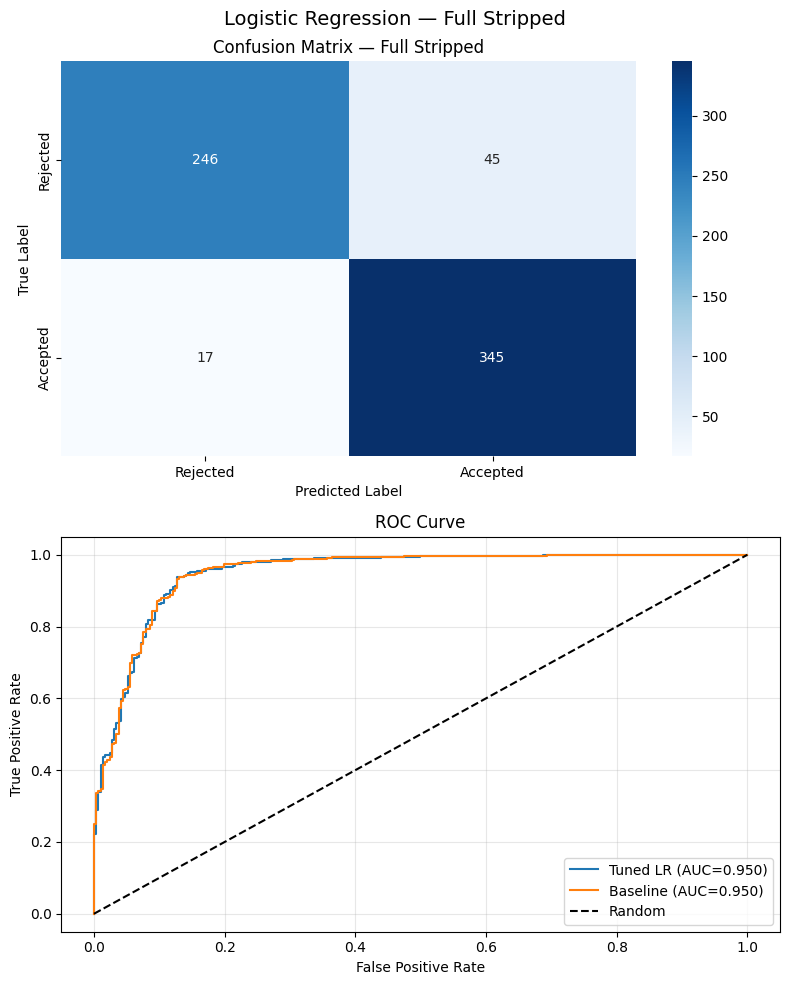


Dataset: Full Prefixed
Train size: 2612  Test size: 653

── Baseline Logistic Regression (defaults) ────────────
Accuracy:  0.8897
Precision: 0.9028
Recall:    0.8978
F1:        0.9003
ROC-AUC:   0.9503

Tuning Logistic Regression (RandomizedSearchCV)...

── Tuned Logistic Regression vs Baseline ──────────────
Best CV ROC-AUC: 0.9492
Best parameters:
  alpha: 0.00018057016569070425
  l1_ratio: 0.4
  penalty: elasticnet
Accuracy:  0.8882  (baseline: 0.8897)
Precision: 0.8773  (baseline: 0.9028)
Recall:    0.9282  (baseline: 0.8978)
F1:        0.9020  (baseline: 0.9003)
ROC-AUC:   0.9472  (baseline: 0.9503)

── Classification Report ──────────────────────────────
              precision    recall  f1-score   support

    Rejected       0.90      0.84      0.87       291
    Accepted       0.88      0.93      0.90       362

    accuracy                           0.89       653
   macro avg       0.89      0.88      0.89       653
weighted avg       0.89      0.89      0.89       653



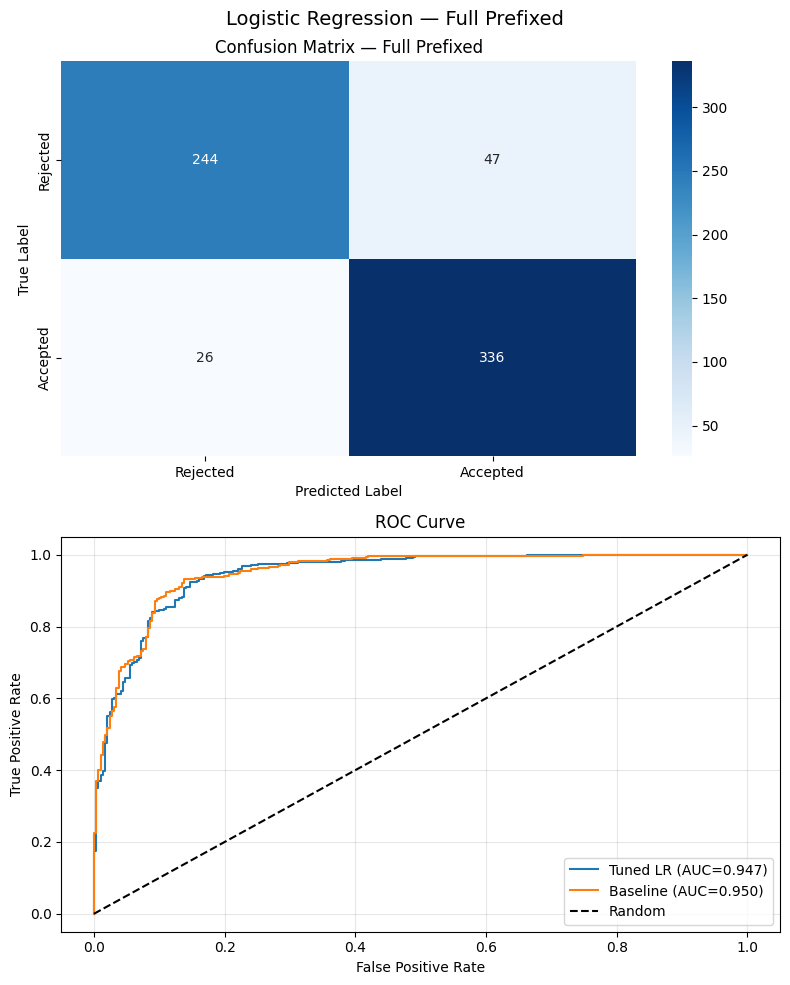

In [47]:
lr_results = {}

for name in datasets.keys():
    split = splits[name]
    _, metrics = run_logistic_regression_classification(
        X_train=split['X_train'],
        X_test=split['X_test'],
        y_train=split['y_train'],
        y_test=split['y_test'],
        dataset_name=name,
        n_iter=50
    )
    lr_results[name] = metrics

In [48]:
summary_lr = pd.DataFrame([
    {
        'Dataset': name,
        'CV ROC-AUC': res['cv_roc_auc'],
        'Test ROC-AUC': res['test_roc_auc'],
        'Test Accuracy': res['test_accuracy'],
        'Best Params': res['best_params']
    }
    for name, res in lr_results.items()
])
display(summary_lr)

,Dataset,CV ROC-AUC,Test ROC-AUC,Test Accuracy,Best Params
0,Reduced Stripped,0.946310,0.944068,0.892802,"{'alpha': 0.000205399898260439, 'l1_ratio': 0...."
1,Reduced Prefixed,0.942899,0.940589,0.883614,"{'alpha': 0.000254064590662387, 'l1_ratio': 0...."
2,Full Stripped,0.952304,0.950219,0.905054,"{'alpha': 0.00013734633932438524, 'l1_ratio': ..."
3,Full Prefixed,0.949167,0.947182,0.888208,"{'alpha': 0.00018057016569070425, 'l1_ratio': ..."


In [49]:
all_results = []

for dataset, metrics in bagging_results.items():
    all_results.append({
        'Dataset': dataset,
        'Model': 'Bagging',
        'Test ROC‑AUC': metrics['test_roc_auc'],
        'Test Accuracy': metrics['test_accuracy'],
    })

for dataset, metrics in rf_results.items():
    all_results.append({
        'Dataset': dataset,
        'Model': 'Random Forest',
        'Test ROC‑AUC': metrics['test_roc_auc'],
        'Test Accuracy': metrics['test_accuracy'],
    })

for dataset, metrics in xgb_results.items():
    all_results.append({
        'Dataset': dataset,
        'Model': 'XGBoost',
        'Test ROC‑AUC': metrics['test_roc_auc'],
        'Test Accuracy': metrics['test_accuracy'],
    })

for dataset, metrics in svm_results.items():
    all_results.append({
        'Dataset': dataset,
        'Model': 'SVM',
        'Test ROC‑AUC': metrics['test_roc_auc'],
        'Test Accuracy': metrics['test_accuracy'],
    })

for dataset, metrics in lr_results.items():
    all_results.append({
        'Dataset': dataset,
        'Model': 'Logistic Regression',
        'Test ROC‑AUC': metrics['test_roc_auc'],
        'Test Accuracy': metrics['test_accuracy'],
    })

summary_df = pd.DataFrame(all_results)

styled_summary_model_comparison = (summary_df
    .pivot(index='Dataset', columns='Model', values='Test ROC‑AUC')
    .style
    .background_gradient(cmap='RdYlGn', axis=1)
    .format("{:.3f}")
    .set_caption('Test ROC‑AUC by Dataset and Model')
    .set_properties(**{'text-align': 'center'})
)

display(styled_summary_model_comparison)

styled_acc_model_comparison = (summary_df
    .pivot(index='Dataset', columns='Model', values='Test Accuracy')
    .style
    .background_gradient(cmap='Blues', axis=1)
    .format("{:.3f}")
    .set_caption('Test Accuracy by Dataset and Model')
    .set_properties(**{'text-align': 'center'})
)

display(styled_acc_model_comparison)

styled_summary_dataset_comparison = (summary_df
    .pivot(index='Dataset', columns='Model', values='Test ROC‑AUC')
    .style
    .background_gradient(cmap='RdYlGn', axis=0)
    .format("{:.3f}")
    .set_caption('Test ROC‑AUC by Dataset and Model')
    .set_properties(**{'text-align': 'center'})
)

display(styled_summary_dataset_comparison)

styled_acc_dataset_comparison = (summary_df
    .pivot(index='Dataset', columns='Model', values='Test Accuracy')
    .style
    .background_gradient(cmap='Blues', axis=0)
    .format("{:.3f}")
    .set_caption('Test Accuracy by Dataset and Model')
    .set_properties(**{'text-align': 'center'})
)

display(styled_acc_dataset_comparison)

Model,Bagging,Logistic Regression,Random Forest,SVM,XGBoost
Dataset,,,,,
Full Prefixed,0.930,0.947,0.936,0.946,0.934
Full Stripped,0.934,0.950,0.936,0.944,0.927
Reduced Prefixed,0.921,0.941,0.929,0.933,0.928
Reduced Stripped,0.936,0.944,0.940,0.941,0.936


Model,Bagging,Logistic Regression,Random Forest,SVM,XGBoost
Dataset,,,,,
Full Prefixed,0.856,0.888,0.861,0.891,0.867
Full Stripped,0.861,0.905,0.862,0.907,0.868
Reduced Prefixed,0.842,0.884,0.856,0.873,0.861
Reduced Stripped,0.862,0.893,0.859,0.893,0.862


Model,Bagging,Logistic Regression,Random Forest,SVM,XGBoost
Dataset,,,,,
Full Prefixed,0.930,0.947,0.936,0.946,0.934
Full Stripped,0.934,0.950,0.936,0.944,0.927
Reduced Prefixed,0.921,0.941,0.929,0.933,0.928
Reduced Stripped,0.936,0.944,0.940,0.941,0.936


Model,Bagging,Logistic Regression,Random Forest,SVM,XGBoost
Dataset,,,,,
Full Prefixed,0.856,0.888,0.861,0.891,0.867
Full Stripped,0.861,0.905,0.862,0.907,0.868
Reduced Prefixed,0.842,0.884,0.856,0.873,0.861
Reduced Stripped,0.862,0.893,0.859,0.893,0.862
